In [28]:
# =================================================
# Create unique experiment directory 
# =================================================

from datetime import datetime
import re
from pathlib import Path
import yaml

PROJECT_ROOT = Path().resolve().parent # go up one level

# Load feature config
feature_cfg_path = PROJECT_ROOT / "feature_config.yaml"
with open(feature_cfg_path, "r") as f:
    feature_config = yaml.safe_load(f)

FEATURE_VERSION = feature_config["feature_version"]
MODEL_TYPE = feature_config["model_type"]   # "summary_stats" or "time_series"

# --- makes label for the experiment ---
def start_run(label: str = "baseline") -> Path:
    ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    
    # put MODEL_TYPE under experiments
    root = PROJECT_ROOT / "experiments" / MODEL_TYPE
    root.mkdir(parents=True, exist_ok=True)
    
    existing = sorted(root.glob(f"{ts}_run-*_{label}"))
    idx = 1
    if existing:
        m = re.search(r"_run-(\d{3})_", existing[-1].name)
        idx = (int(m.group(1)) + 1) if m else 1
    
    rd = root / f"{ts}_run-{idx:03d}_{label}"
    rd.mkdir(parents=True, exist_ok=True)
    print(f"[INFO] Run directory: {rd}")
    return rd

run_dir = start_run("baseline")

[INFO] Run directory: /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline


In [29]:

# =================================================
# Step 0: Import Libraries and Create Models
# =================================================

from __future__ import annotations
from pathlib import Path
from joblib import dump, load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import re

# --- sklearn ---
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score, average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score as _f1_for_perm
from sklearn.model_selection import GridSearchCV, StratifiedKFold, GroupKFold
from sklearn.metrics import make_scorer, f1_score, average_precision_score, brier_score_loss

from sklearn.metrics import (
    precision_recall_fscore_support, average_precision_score,
    roc_auc_score, brier_score_loss
)
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    average_precision_score, roc_auc_score
)
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, brier_score_loss,
    confusion_matrix
)

# --- Plotting Util (saves CM, PR, calibration) ---
from plots import save_all_eval_figures

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)

# --- Load Project Config ---
project_cfg_path = PROJECT_ROOT / "project_config.yaml"
with open(project_cfg_path, "r") as f:
    project_config = yaml.safe_load(f)

ATHLETE = project_config["athlete"]
SESSION = project_config["session"]

LABELS = ["miss", "make"]                # row/col order in CM: 0->miss, 1->make
LABEL_TO_INT = {"miss": 0, "make": 1}
INT_TO_LABEL = {0: "miss", 1: "make"}

POS_LABEL = "make"                        # human-friendly
POS_LABEL_INT = LABEL_TO_INT[POS_LABEL]   # = 0  (positive class is miss)

# --- Load Feature Config ---
feature_cfg_path = PROJECT_ROOT / "feature_config.yaml"
with open(feature_cfg_path, "r") as f:
    feature_config = yaml.safe_load(f)

FEATURE_VERSION = feature_config["feature_version"] # version of feature data set 
MODEL_TYPE = feature_config["model_type"] # summary_stats or time_series

# --- Paths and Directories ---
DATA_ROOT = PROJECT_ROOT / "data" / ATHLETE

SESSIONS = {
    "session_01": DATA_ROOT / "session_01" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_02": DATA_ROOT / "session_02" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_03": DATA_ROOT / "session_03" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_04": DATA_ROOT / "session_04" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION
    # add more sessions here...
}

In [31]:
# =================================================
# Step 1: Split data into train/validation and test
# =================================================

TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
session_train_list, session_test_list = [], []

for session_name, base in SESSIONS.items():
    # Load
    X = pd.read_csv(base / "X.csv")
    y = pd.read_csv(base / "y.csv").squeeze("columns").astype(int)

    # Stratify class proportions based on y (makes/misses)
    strat = y if y.nunique() > 1 else None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=strat 
    )

    # Store with session labels
    X_train_list.append(X_tr) 
    X_test_list.append(X_te)
    y_train_list.append(y_tr)
    y_test_list.append(y_te)
    session_train_list.extend([session_name] * len(y_tr))
    session_test_list.extend([session_name] * len(y_te))

# Concatenate everything
X_train = pd.concat(X_train_list, ignore_index=True)
X_test  = pd.concat(X_test_list, ignore_index=True)
y_train = pd.concat(y_train_list, ignore_index=True)
y_test  = pd.concat(y_test_list, ignore_index=True)
session_train = pd.Series(session_train_list, name="session")
session_test  = pd.Series(session_test_list, name="session")

# Print feature names
print("\n[FEATURES included]")
for i, col in enumerate(X_train.columns, start=1):
    print(f"{i:3d}. {col}")

# print shape and counts
print("[INFO] Train shape:", X_train.shape, "Test shape:", X_test.shape)
name_map = {0: "miss", 1: "make"}

print("\n[TRAIN counts]")
train_counts = pd.crosstab(session_train, y_train.map(name_map), margins=True, margins_name="Total")
print(train_counts)

print("\n[TEST counts]")
test_counts = pd.crosstab(session_test, y_test.map(name_map), margins=True, margins_name="Total")
print(test_counts)



[FEATURES included]
  1. windup_duration
  2. follow_duration
  3. total_duration
  4. fps
  5. pre_frames
  6. post_frames
  7. mask@-6
  8. mask@-5
  9. mask@-4
 10. mask@-3
 11. mask@-2
 12. mask@-1
 13. mask@+0
 14. elbow_flex_l@-6
 15. elbow_flex_l@-5
 16. elbow_flex_l@-4
 17. elbow_flex_l@-3
 18. elbow_flex_l@-2
 19. elbow_flex_l@-1
 20. elbow_flex_l@+0
 21. elbow_flex_r@-6
 22. elbow_flex_r@-5
 23. elbow_flex_r@-4
 24. elbow_flex_r@-3
 25. elbow_flex_r@-2
 26. elbow_flex_r@-1
 27. elbow_flex_r@+0
 28. shoulder_flex_l@-6
 29. shoulder_flex_l@-5
 30. shoulder_flex_l@-4
 31. shoulder_flex_l@-3
 32. shoulder_flex_l@-2
 33. shoulder_flex_l@-1
 34. shoulder_flex_l@+0
 35. shoulder_flex_r@-6
 36. shoulder_flex_r@-5
 37. shoulder_flex_r@-4
 38. shoulder_flex_r@-3
 39. shoulder_flex_r@-2
 40. shoulder_flex_r@-1
 41. shoulder_flex_r@+0
 42. hip_flex_l@-6
 43. hip_flex_l@-5
 44. hip_flex_l@-4
 45. hip_flex_l@-3
 46. hip_flex_l@-2
 47. hip_flex_l@-1
 48. hip_flex_l@+0
 49. hip_flex_r@-6
 5

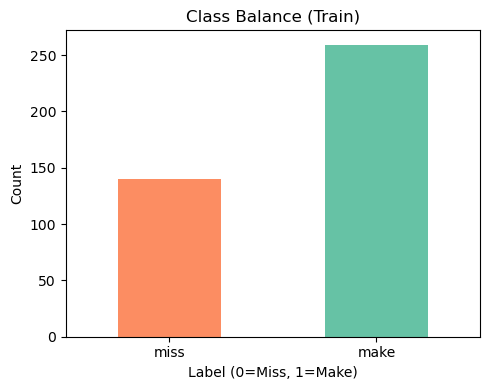

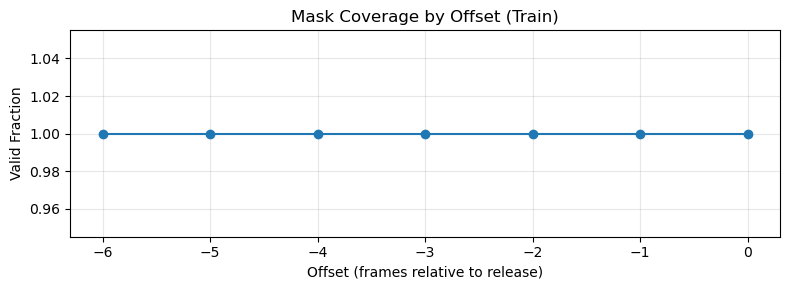

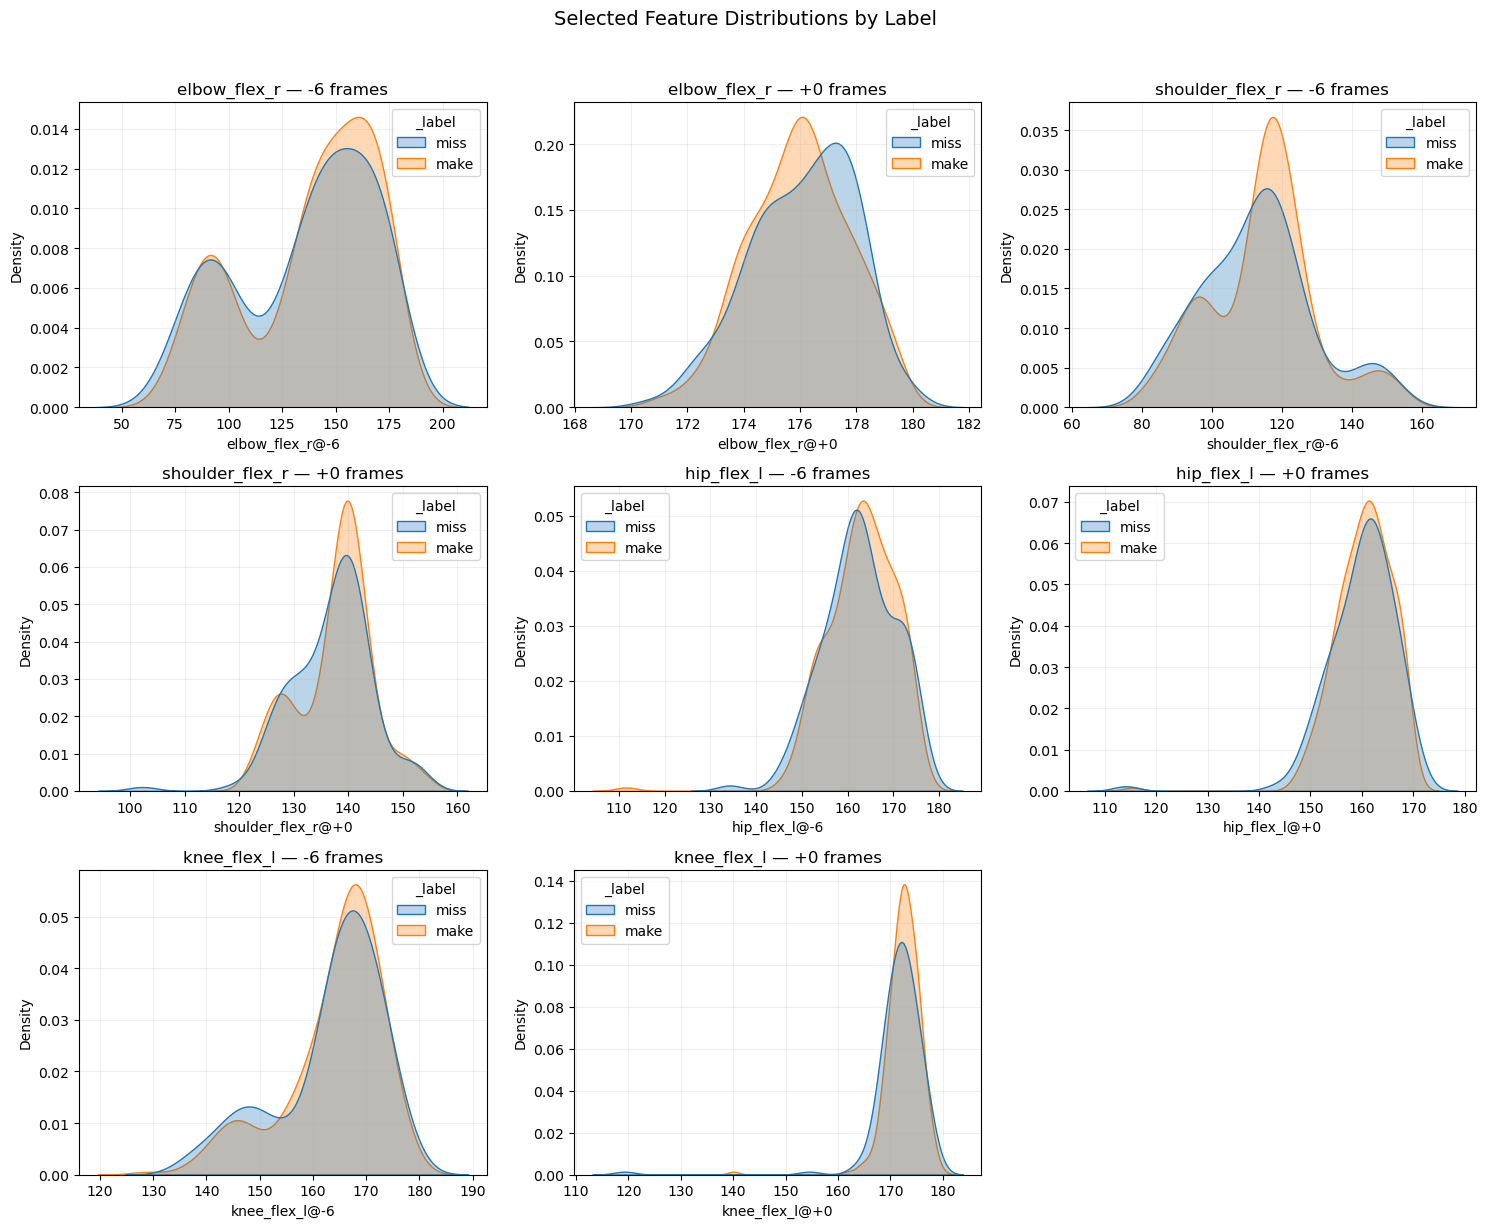

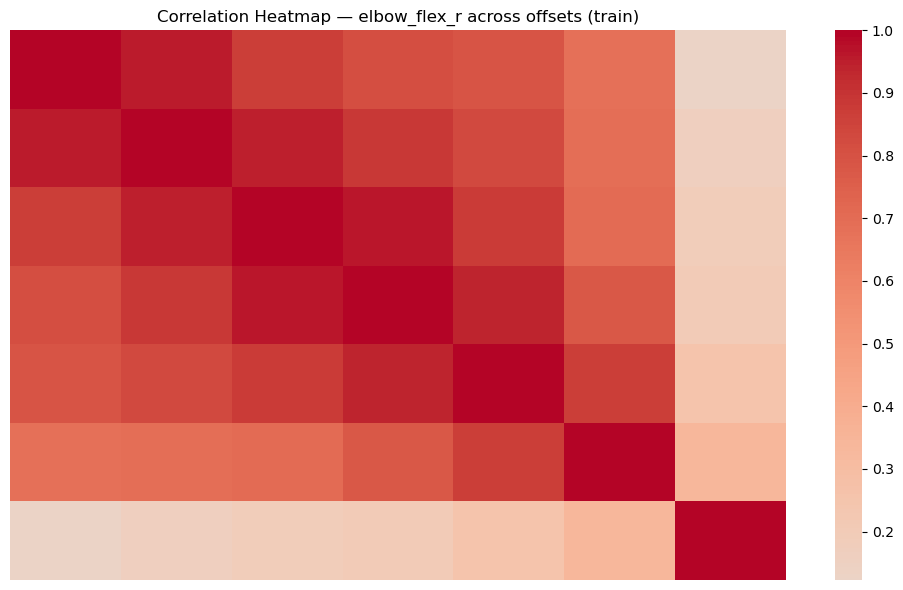

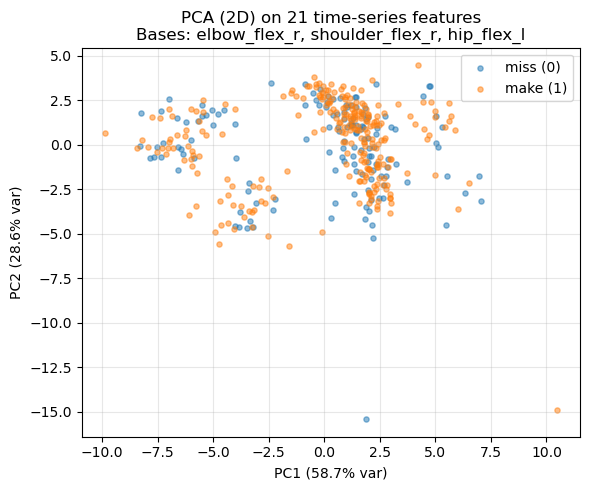

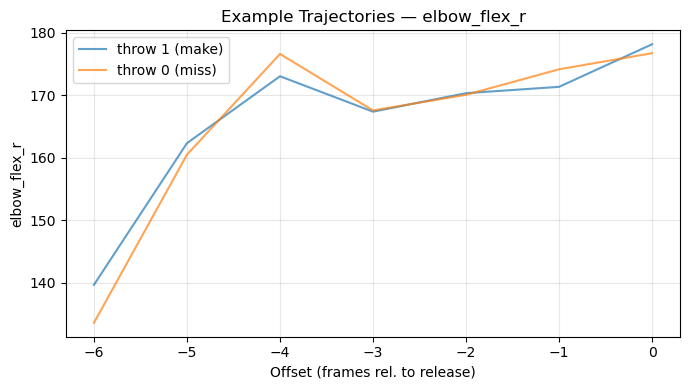

In [32]:
# =================================================
# A. Pre-Modeling EDA  — time_series friendly
# =================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ----------------------------
# Helpers
# ----------------------------
def parse_offset(col):
    """Return int offset from a 'name@+/-k' column, else None."""
    m = re.search(r'@([+-]?\d+)$', col)
    return int(m.group(1)) if m else None

def angle_base(col):
    """Return base part before '@', else original col."""
    return col.split('@')[0] if '@' in col else col

def cols_for_angle(base, X):
    """All columns for given angle base, sorted by offset."""
    cs = [c for c in X.columns if c.startswith(base + '@')]
    return sorted(cs, key=parse_offset)

def nearest_offsets(existing_offsets, want):
    """Map desired offsets to nearest available ones."""
    ex = np.array(existing_offsets)
    out = []
    for w in want:
        idx = int(np.argmin(np.abs(ex - w)))
        out.append(int(ex[idx]))
    return sorted(set(out), key=lambda z: (z,))

def list_angle_bases(X, max_n=6):
    """Heuristic: return up to max_n angle names (before '@')."""
    bases = []
    for c in X.columns:
        if '@' in c and not c.startswith('mask@'):
            b = angle_base(c)
            if b not in bases:
                bases.append(b)
        if len(bases) >= max_n:
            break
    return bases

# ----------------------------
# Inputs assumed available:
# X_train, y_train  (from your split)
# ----------------------------

# 1) Display Class Balance 
plt.figure(figsize=(5,4))
y_train.value_counts().sort_index().plot(kind="bar", color=["#fc8d62", "#66c2a5"])
plt.title("Class Balance (Train)")
plt.xlabel("Label (0=Miss, 1=Make)")
plt.ylabel("Count")
plt.xticks([0, 1], ["miss", "make"], rotation=0)
plt.tight_layout()
plt.show()

# 2) Display Mask Coverage (troughs mean data does not exist for some free throws in that range)
mask_cols = [c for c in X_train.columns if c.startswith("mask@")]
if mask_cols:
    offs = np.array([parse_offset(c) for c in mask_cols])
    order = np.argsort(offs)
    offs_sorted = offs[order]
    mask_mat = X_train[mask_cols].to_numpy()[:, order]
    coverage = mask_mat.mean(axis=0)  # fraction valid at each offset

    plt.figure(figsize=(8,3))
    plt.plot(offs_sorted, coverage, marker='o')
    plt.title("Mask Coverage by Offset (Train)")
    plt.xlabel("Offset (frames relative to release)")
    plt.ylabel("Valid Fraction")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3.) Targeted distributions for a few angles & offsets 
y_named = y_train.map({0: "miss", 1: "make"})

ANGLE_BASES = [
    "elbow_flex_r",
    "shoulder_flex_r",
    "hip_flex_l",
    "knee_flex_l"
]
DESIRED_OFFSETS = [-30, -15, 0, +15, +30]  # configure 
MAX_PLOTS = 30

plots = []
for base in ANGLE_BASES:
    cols = cols_for_angle(base, X_train)
    if not cols:
        continue
    existing_offsets = [parse_offset(c) for c in cols]
    chosen = nearest_offsets(existing_offsets, DESIRED_OFFSETS)
    chosen_cols = [f"{base}@{o:+d}" for o in chosen if f"{base}@{o:+d}" in X_train.columns]
    for c in chosen_cols:
        plots.append((base, c))

plots = plots[:MAX_PLOTS]

n = len(plots)
if n:
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (base, col) in zip(axes, plots):
        sns.kdeplot(data=X_train, x=col, hue=y_named, common_norm=False, ax=ax, fill=True, alpha=0.3)
        ax.set_title(f"{base} — {col.split('@')[-1]} frames")
        ax.grid(True, alpha=0.2)

    # hide any unused axes
    for ax in axes[len(plots):]:
        ax.axis('off')

    fig.suptitle("Selected Feature Distributions by Label", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

# 4) Correlation heatmap for one angle across all offsets
if ANGLE_BASES:
    base = ANGLE_BASES[0]  # first angle base
    cols = cols_for_angle(base, X_train)
    if len(cols) >= 3:  # need a few
        corr = X_train[cols].corr()
        plt.figure(figsize=(10, 6))
        sns.heatmap(corr, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
        plt.title(f"Correlation Heatmap — {base} across offsets (train)")
        plt.tight_layout()
        plt.show()

# 5) PCA scatter on a compact, meaningful subset
#    Use a few angle bases (<= 3) over all their offsets, scale, then 2D PCA scatter.
PCA_BASES = ANGLE_BASES[:3]  # up to 3 bases
pca_cols = []
for b in PCA_BASES:
    pca_cols.extend(cols_for_angle(b, X_train))
pca_cols = list(dict.fromkeys(pca_cols))  # unique, ordered

# avoid including mask columns
pca_cols = [c for c in pca_cols if not c.startswith("mask@")]

if len(pca_cols) >= 5:
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xp = scaler.fit_transform(X_train[pca_cols].to_numpy())
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(Xp)

    plt.figure(figsize=(6,5))
    plt.scatter(Z[y_train==0, 0], Z[y_train==0, 1], s=14, alpha=0.5, label="miss (0)")
    plt.scatter(Z[y_train==1, 0], Z[y_train==1, 1], s=14, alpha=0.5, label="make (1)")
    plt.title(f"PCA (2D) on {len(pca_cols)} time-series features\nBases: {', '.join(PCA_BASES)}")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 5) Optional: single-throw trajectory visualization for a couple angles
#    (super helpful sanity check)
if ANGLE_BASES:
    # pick one or two throws per class (if available)
    idx_make = np.where(y_train.values == 1)[0][:1]
    idx_miss = np.where(y_train.values == 0)[0][:1]
    pick = list(idx_make) + list(idx_miss)

    # x-axis = offsets for the chosen angle
    base = ANGLE_BASES[0]
    cols = cols_for_angle(base, X_train)
    offs = [parse_offset(c) for c in cols]

    plt.figure(figsize=(7,4))
    for i in pick:
        lab = "make" if y_train.iloc[i] == 1 else "miss"
        plt.plot(offs, X_train.iloc[i][cols].values.astype(float), alpha=0.7, label=f"throw {i} ({lab})")
    plt.title(f"Example Trajectories — {base}")
    plt.xlabel("Offset (frames rel. to release)")
    plt.ylabel(base)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


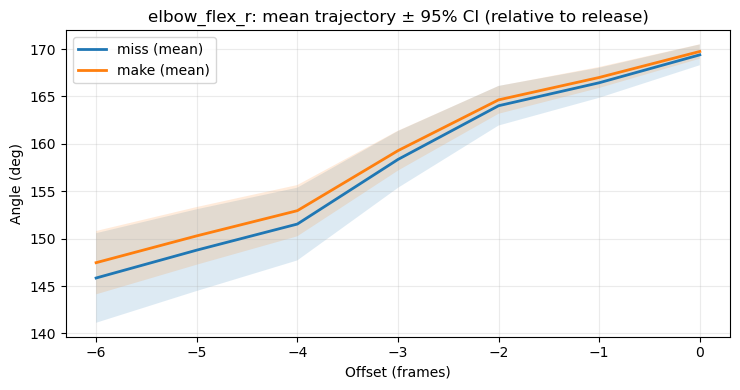

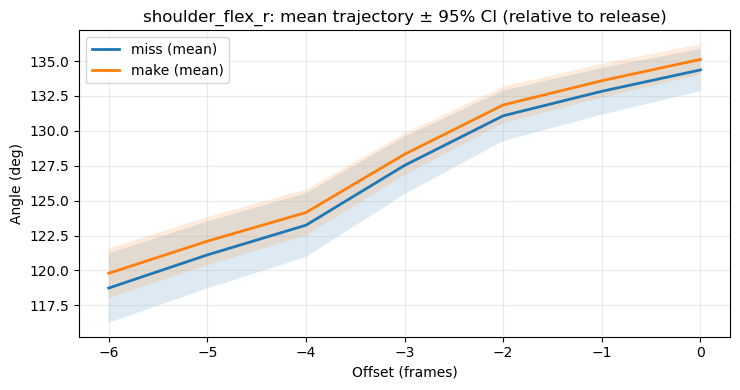

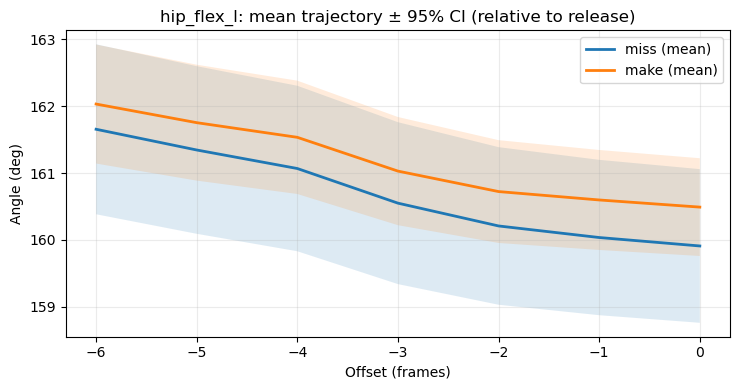

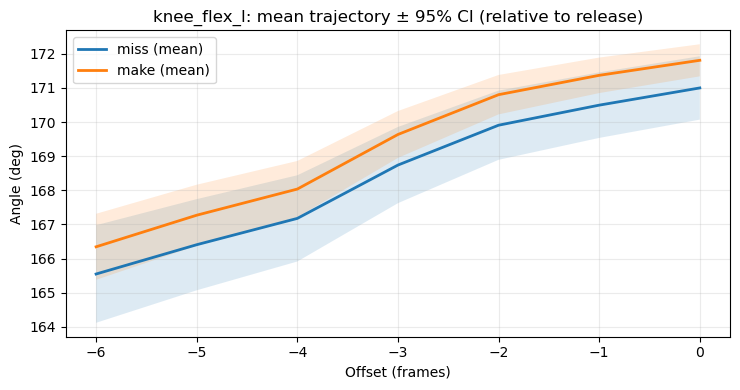

In [33]:
# ================================
# Trajectory plots by label (make/miss)
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

POS_LABEL_INT = 0  # 0=miss, 1=make

def parse_offset(col):
    """Extract integer offset from 'foo@-15' -> -15; returns None if not present."""
    try:
        return int(str(col).rsplit('@', 1)[1])
    except Exception:
        return None

def cols_for_angle(base, X):
    """All columns for a given angle base (e.g., 'elbow_flex_r')."""
    return [c for c in X.columns if isinstance(c, str) and c.startswith(f"{base}@")]

def available_offsets(base, X):
    offs = [parse_offset(c) for c in cols_for_angle(base, X)]
    return sorted([o for o in offs if o is not None])

def angle_matrix(X, base):
    """
    Return:
      offs_sorted: list[int] offsets present
      A: np.ndarray (n_samples, T) of the angle at each offset
         with invalid frames masked to NaN if mask@offset exists and is 0.
    """
    offs = available_offsets(base, X)
    cols = [f"{base}@{o:+d}" for o in offs]
    A = X[cols].to_numpy(dtype=float)

    # Apply masks if present: set invalid to NaN
    mask_cols = [f"mask@{o:+d}" for o in offs]
    missing_mask_cols = [m for m in mask_cols if m not in X.columns]
    if len(missing_mask_cols) < len(mask_cols):
        # Only apply for columns that exist
        M = np.ones_like(A, dtype=bool)
        for j, o in enumerate(offs):
            mc = f"mask@{o:+d}"
            if mc in X.columns:
                M[:, j] = X[mc].to_numpy(dtype=bool)
        A = np.where(M, A, np.nan)
    return offs, A

def mean_ci(y_vals, axis=0):
    """Mean and 95% CI ignoring NaNs."""
    m  = np.nanmean(y_vals, axis=axis)
    sd = np.nanstd(y_vals,  axis=axis, ddof=1)
    n  = np.sum(~np.isnan(y_vals), axis=axis).astype(float)
    se = sd / np.sqrt(np.maximum(n, 1.0))
    ci = 1.96 * se
    return m, ci, n

def maybe_smooth(arr, window=3):
    if window is None or window <= 1:
        return arr
    # simple centered moving average; handle NaNs
    s = pd.Series(arr)
    return s.rolling(window=window, center=True, min_periods=1).mean().to_numpy()

def plot_trajectory(base, X, y, smooth_window=3):
    offs, A = angle_matrix(X, base)
    if len(offs) == 0:
        print(f"[WARN] No offsets for base '{base}'.")
        return

    miss = (y == 0).values
    make = (y == 1).values

    m_miss, ci_miss, n_miss = mean_ci(A[miss, :], axis=0)
    m_make, ci_make, n_make = mean_ci(A[make, :], axis=0)

    if smooth_window and smooth_window > 1:
        m_miss = maybe_smooth(m_miss, smooth_window)
        ci_miss = maybe_smooth(ci_miss, smooth_window)
        m_make = maybe_smooth(m_make, smooth_window)
        ci_make = maybe_smooth(ci_make, smooth_window)

    plt.figure(figsize=(7.5, 4))
    # mean curves
    plt.plot(offs, m_miss, label="miss (mean)", linewidth=2)
    plt.plot(offs, m_make, label="make (mean)", linewidth=2)
    # shaded 95% CI
    plt.fill_between(offs, m_miss - ci_miss, m_miss + ci_miss, alpha=0.15)
    plt.fill_between(offs, m_make - ci_make, m_make + ci_make, alpha=0.15)

    # coverage ticks (optional): show fraction valid at each offset
    # uncomment to see on secondary axis
    # coverage = np.nanmean(~np.isnan(A), axis=0)
    # ax = plt.gca().twinx()
    # ax.plot(offs, coverage, linestyle="--", alpha=0.4, label="coverage")
    # ax.set_ylabel("valid fraction")

    plt.title(f"{base}: mean trajectory ± 95% CI (relative to release)")
    plt.xlabel("Offset (frames)")
    plt.ylabel("Angle (deg)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --------- USAGE ---------
# Pick the exact bases you want to view (examples below)
ANGLE_BASES_TO_VIEW = [
    "elbow_flex_r",
    "shoulder_flex_r",
    "hip_flex_l",
    "knee_flex_l",
]

for base in ANGLE_BASES_TO_VIEW:
    plot_trajectory(base, X_train, y_train, smooth_window=5)  # try 3–7 for smoothing


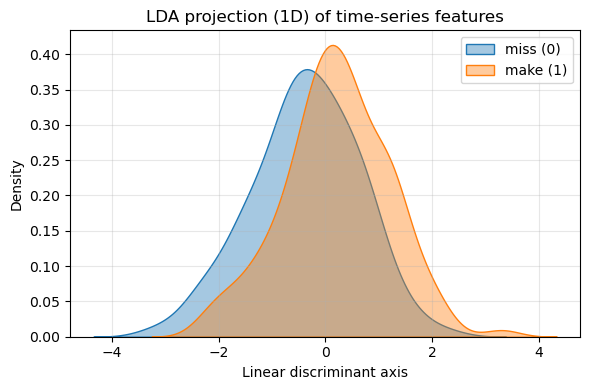

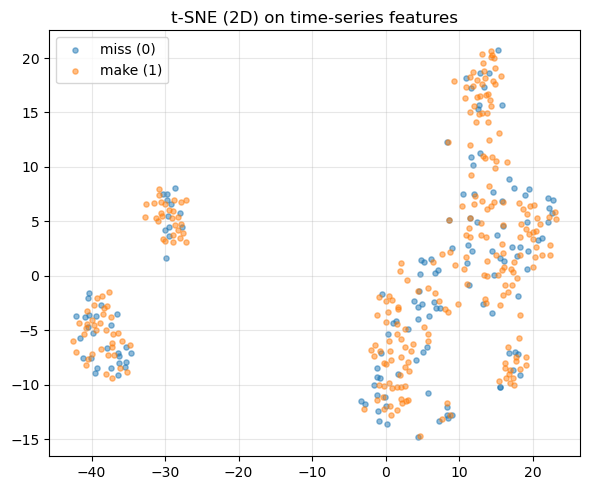

/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


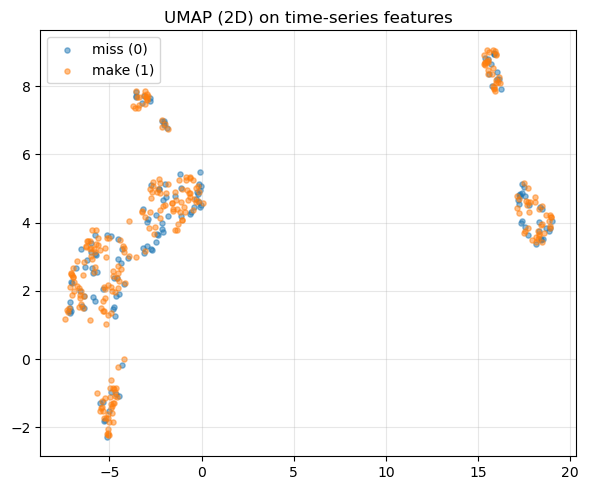

In [34]:


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import seaborn as sns

# same features you used for PCA
Xp = scaler.fit_transform(X_train[pca_cols].to_numpy())
lda = LinearDiscriminantAnalysis(n_components=1)
Z = lda.fit_transform(Xp, y_train)

plt.figure(figsize=(6,4))
sns.kdeplot(Z[y_train==0, 0], label="miss (0)", fill=True, alpha=0.4)
sns.kdeplot(Z[y_train==1, 0], label="make (1)", fill=True, alpha=0.4)
plt.title("LDA projection (1D) of time-series features")
plt.xlabel("Linear discriminant axis")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




from sklearn.manifold import TSNE

Xp = scaler.fit_transform(X_train[pca_cols].to_numpy())
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200)
Z = tsne.fit_transform(Xp)

plt.figure(figsize=(6,5))
plt.scatter(Z[y_train==0, 0], Z[y_train==0, 1], s=14, alpha=0.5, label="miss (0)")
plt.scatter(Z[y_train==1, 0], Z[y_train==1, 1], s=14, alpha=0.5, label="make (1)")
plt.title("t-SNE (2D) on time-series features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



import umap

Xp = scaler.fit_transform(X_train[pca_cols].to_numpy())
umap_model = umap.UMAP(n_components=2, random_state=42)
Z = umap_model.fit_transform(Xp)

plt.figure(figsize=(6,5))
plt.scatter(Z[y_train==0, 0], Z[y_train==0, 1], s=14, alpha=0.5, label="miss (0)")
plt.scatter(Z[y_train==1, 0], Z[y_train==1, 1], s=14, alpha=0.5, label="make (1)")
plt.title("UMAP (2D) on time-series features")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [35]:
# =========================================
# LDA vs Logistic Regression (CV diagnostic)
# =========================================
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score, make_scorer
)

POS_LABEL_INT = 0  # 0=miss, 1=make

# --- choose feature set: keep what you used for PCA or just use all time-series angle@* (no masks)
def is_angle_col(c): return isinstance(c, str) and ('@' in c) and (not c.startswith('mask@'))
feat_cols = [c for c in X_train.columns if is_angle_col(c)]

X = X_train[feat_cols]
y = y_train.astype(int)

# --- models
lda_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LinearDiscriminantAnalysis(solver="svd"))  # svd is stable; no shrinkage needed for CV here
])

logreg_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced"))
])

models = {
    "LDA": lda_pipe,
    "LogReg": logreg_pipe,
}

# --- CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def eval_model(name, pipe):
    # get probability of 'miss' (class 0) via cross-val
    if hasattr(pipe.steps[-1][1], "predict_proba"):
        method = "predict_proba"
    else:
        # LDA and LogReg both have predict_proba; this is just a safety net
        method = "decision_function"

    if method == "predict_proba":
        proba = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba", n_jobs=-1)
        # classes are [0,1] -> index 0 is 'miss'
        p_pos = proba[:, 0]
    else:
        df = cross_val_predict(pipe, X, y, cv=cv, method="decision_function", n_jobs=-1)
        # decision_function is w.r.t class 1; flip sign for pos=0 and squash
        from scipy.special import expit
        if df.ndim == 1:
            p_pos = expit(-df)
        else:
            # multi-class path (won't happen here)
            p_pos = expit(df[:, 0])

    # choose threshold that maximizes F1(pos=miss) on out-of-fold preds
    ts = np.linspace(0.05, 0.95, 181)
    best_f1, best_t = -1.0, 0.5
    for t in ts:
        yhat = (p_pos >= t).astype(int)
        f1 = f1_score(y, yhat, pos_label=POS_LABEL_INT, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    # final metrics using that threshold
    yhat = (p_pos >= best_t).astype(int)
    prec = precision_score(y, yhat, pos_label=POS_LABEL_INT, zero_division=0)
    rec  = recall_score(y, yhat,    pos_label=POS_LABEL_INT, zero_division=0)
    ap   = average_precision_score(y, p_pos, pos_label=POS_LABEL_INT)
    roc  = roc_auc_score(y, p_pos)

    return {
        "model": name,
        "features": len(feat_cols),
        "best_thr(P(miss))": best_t,
        "F1(miss)": best_f1,
        "Precision(miss)": prec,
        "Recall(miss)": rec,
        "AP(pos=miss)": ap,
        "ROC_AUC": roc,
    }

results = [eval_model(n, m) for n, m in models.items()]
pd.DataFrame(results).sort_values("F1(miss)", ascending=False)


,model,features,best_thr(P(miss)),F1(miss),Precision(miss),Recall(miss),AP(pos=miss),ROC_AUC
0,LDA,70,0.95,0.522388,0.353535,1.000000,0.393585,0.438389
1,LogReg,70,0.86,0.521576,0.353690,0.992857,0.395585,0.422311


In [36]:
# =================================================
# Step 2: Tune model hyperparameters  (Time-Series A, STRATIFIED)
#  - StratifiedKFold CV (keeps class balance)
#  - Release-frame jitter (train folds only)
# =================================================

import re
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    make_scorer, f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# --- score extractors that respect POS_LABEL and work with Pipelines ---

def _classes_of(est):
    if hasattr(est, "classes_"):
        return est.classes_
    if isinstance(est, Pipeline):
        return _classes_of(est.steps[-1][1])
    if hasattr(est, "best_estimator_"):
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")

def get_pos_scores(est, X, pos_label):
    # Prefer predict_proba; fallback to decision_function
    if hasattr(est, "predict_proba"):
        proba = est.predict_proba(X)
        classes = list(_classes_of(est))
        idx = classes.index(pos_label)
        return proba[:, idx]
    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        classes = list(_classes_of(est))
        if df.ndim == 1:
            return df if pos_label == classes[1] else -df
        idx = classes.index(pos_label)
        return df[:, idx]
    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

def ap_pos_scorer(est, X, y):
    s = get_pos_scores(est, X, POS_LABEL_INT)
    return average_precision_score(y, s, pos_label=POS_LABEL_INT)

def roc_pos_scorer(est, X, y):
    # Ensure ROC is computed for the *chosen* positive class
    s = get_pos_scores(est, X, POS_LABEL_INT)
    y_pos = (y == POS_LABEL_INT).astype(int)
    return roc_auc_score(y_pos, s)

# =================================================
# Jitter transformer (train-fol﻿d only)
# =================================================

def _parse_offset(col: str):
    m = re.search(r'@([+-]?\d+)$', col)
    return int(m.group(1)) if m else None

class ReleaseJitter(BaseEstimator, TransformerMixin):
    """
    Circular-shift each angle's time axis by <=max_jitter frames.
    Applies ONLY during fit (training folds) via fit_transform().
    Validation/test transforms are left untouched.
    Skips 'mask@*' columns.
    """
    def __init__(self, max_jitter=2, random_state=42):
        self.max_jitter = int(max_jitter)
        self.random_state = random_state
        self.angle_groups_ = None

    def _build_groups(self, X):
        import re
        def parse_offset(col: str):
            m = re.search(r'@([+-]?\d+)$', col)
            return int(m.group(1)) if m else None
        def base(c): 
            return c.split('@')[0] if isinstance(c, str) and '@' in c else None

        groups = {}
        # Require a DataFrame so we have column names
        if not hasattr(X, "columns"):
            raise TypeError("ReleaseJitter expects a pandas DataFrame (with '@offset' column names).")
        for i, c in enumerate(X.columns):
            if isinstance(c, str) and c.startswith("mask@"):
                continue
            off = parse_offset(c) if isinstance(c, str) else None
            b = base(c)
            if b is None or off is None:
                continue
            groups.setdefault(b, []).append((off, i))
        # sort indices by offset for each angle base
        self.angle_groups_ = {b: [idx for off, idx in sorted(v, key=lambda z: z[0])]
                              for b, v in groups.items()}

    def fit(self, X, y=None):
        self._build_groups(X)
        return self

    def fit_transform(self, X, y=None, **fit_params):
        # Build groups here too, because Pipeline calls fit_transform directly
        self._build_groups(X)
        if self.max_jitter <= 0 or not self.angle_groups_:
            return X
        rng = np.random.RandomState(self.random_state)
        Xc = X.copy()
        for idxs in self.angle_groups_.values():
            if len(idxs) < 3:
                continue
            k = rng.randint(-self.max_jitter, self.max_jitter + 1)
            if k == 0:
                continue
            vals = Xc.iloc[:, idxs].to_numpy()
            vals = np.roll(vals, shift=k, axis=1)  # circular shift along time axis (columns)
            Xc.iloc[:, idxs] = vals
        return Xc

    def transform(self, X):
        # Leave validation/test untouched
        return X


# =================================================
# MODELS and Pipelines
# =================================================

MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42),
    "LinearSVC": LinearSVC(C=1.0, max_iter=10000, tol=1e-3, class_weight="balanced"),
}

pipelines = {
    "LogisticRegression": Pipeline([
        ("jitter", ReleaseJitter(max_jitter=2, random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", MODELS["LogisticRegression"])
    ]),
    "KNN": Pipeline([
        ("jitter", ReleaseJitter(max_jitter=2, random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", MODELS["KNN"])
    ]),
    "DecisionTree": Pipeline([
        ("clf", MODELS["DecisionTree"])
    ]),
    "RandomForest": Pipeline([
        ("clf", MODELS["RandomForest"])
    ]),
    "GradientBoosting": Pipeline([
        ("clf", MODELS["GradientBoosting"])
    ]),
    "SVM": Pipeline([
        ("jitter", ReleaseJitter(max_jitter=2, random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", MODELS["SVM"])
    ]),
    "LinearSVC": Pipeline([
        ("jitter", ReleaseJitter(max_jitter=2, random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", MODELS["LinearSVC"])
    ]),
}

# =================================================
# Hyperparameter grids
# =================================================
n_samples, n_features = X_train.shape
LINSVC_DUAL = (n_features > n_samples)

param_grids = {
    "LogisticRegression": {
        "clf__C": [0.1, 1.0, 10.0],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],
        "clf__leaf_size": [15, 30],
    },
    "DecisionTree": {
        "clf__max_depth": [None, 4, 8],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 5, 10],
        "clf__max_features": [None, "sqrt"],
    },
    "RandomForest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 4, 8],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 5],
        "clf__max_features": ["sqrt", "log2"],
    },
    "GradientBoosting": {
        "clf__n_estimators": [50, 100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3],
        "clf__subsample": [0.7, 1.0],
    },
    "SVM": {
        "clf__C": [0.3, 1.0, 3.0],
        "clf__gamma": ["scale"],
    },
    "LinearSVC": {
        "clf__C": [0.1, 1.0, 3.0],
        "clf__loss": ["squared_hinge"],
        "clf__tol": [1e-3],
        "clf__max_iter": [20000, 50000],
        "clf__dual": [LINSVC_DUAL],
    },
}

# =================================================
# Stratified CV + scoring
# =================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1_pos": make_scorer(f1_score, pos_label=POS_LABEL_INT),
    "ap_pos": ap_pos_scorer,
    "roc":    roc_pos_scorer,
}

# =================================================
# Grid Search loop
# =================================================
leaderboard_rows = []
best_models = {}

for name, pipe in pipelines.items():
    print(f"\n=== Tuning {name} ===")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        cv=cv,
        scoring=scoring,
        refit="f1_pos",
        n_jobs=-1,
        verbose=0,
        return_train_score=False,
        error_score=np.nan
    )
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    # quick precision/recall on the training set (for the POS class)
    y_pred = grid.best_estimator_.predict(X_train)
    prec = precision_score(y_train, y_pred, pos_label=POS_LABEL_INT, zero_division=0)
    rec  = recall_score(y_train, y_pred, pos_label=POS_LABEL_INT, zero_division=0)

    row = {
        "model": name,
        "best_params": grid.best_params_,
        "cv_f1":  grid.cv_results_["mean_test_f1_pos"][grid.best_index_],
        "cv_ap":  grid.cv_results_["mean_test_ap_pos"][grid.best_index_],
        "cv_roc": grid.cv_results_["mean_test_roc"][grid.best_index_],
        "precision(miss)": prec,
        "recall(miss)": rec,
    }
    leaderboard_rows.append(row)

leaderboard = pd.DataFrame(leaderboard_rows).sort_values("cv_f1", ascending=False).reset_index(drop=True)
print("\n[LEADERBOARD — StratifiedKFold CV F1]")
display(leaderboard)

# =================================================
# Save tuned models
# =================================================
from joblib import dump
save_dir = run_dir / "cv_models"
save_dir.mkdir(parents=True, exist_ok=True)
for name, model in best_models.items():
    dump(model, save_dir / f"best_{name}.joblib")
print(f"[INFO] Saved tuned models to: {save_dir}")



=== Tuning LogisticRegression ===

=== Tuning KNN ===

=== Tuning DecisionTree ===

=== Tuning RandomForest ===

=== Tuning GradientBoosting ===

=== Tuning SVM ===

=== Tuning LinearSVC ===

[LEADERBOARD — StratifiedKFold CV F1]


,model,best_params,cv_f1,cv_ap,cv_roc,precision(miss),recall(miss)
0,DecisionTree,"{'clf__max_depth': 4, 'clf__max_features': 'sq...",0.498372,0.363808,0.520823,0.445993,0.914286
1,LinearSVC,"{'clf__C': 1.0, 'clf__dual': False, 'clf__loss...",0.477440,0.406477,0.553736,0.371345,0.907143
2,LogisticRegression,"{'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__s...",0.471077,0.401739,0.549865,0.372372,0.885714
3,KNN,"{'clf__leaf_size': 15, 'clf__n_neighbors': 3, ...",0.379903,0.359758,0.500984,0.450980,0.492857
4,SVM,"{'clf__C': 0.3, 'clf__gamma': 'scale'}",0.367556,0.355874,0.474739,0.371648,0.692857
5,RandomForest,"{'clf__max_depth': 4, 'clf__max_features': 'lo...",0.363991,0.378233,0.540568,0.756250,0.864286
6,GradientBoosting,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.253953,0.376281,0.501920,0.991667,0.850000


[INFO] Saved tuned models to: /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/cv_models


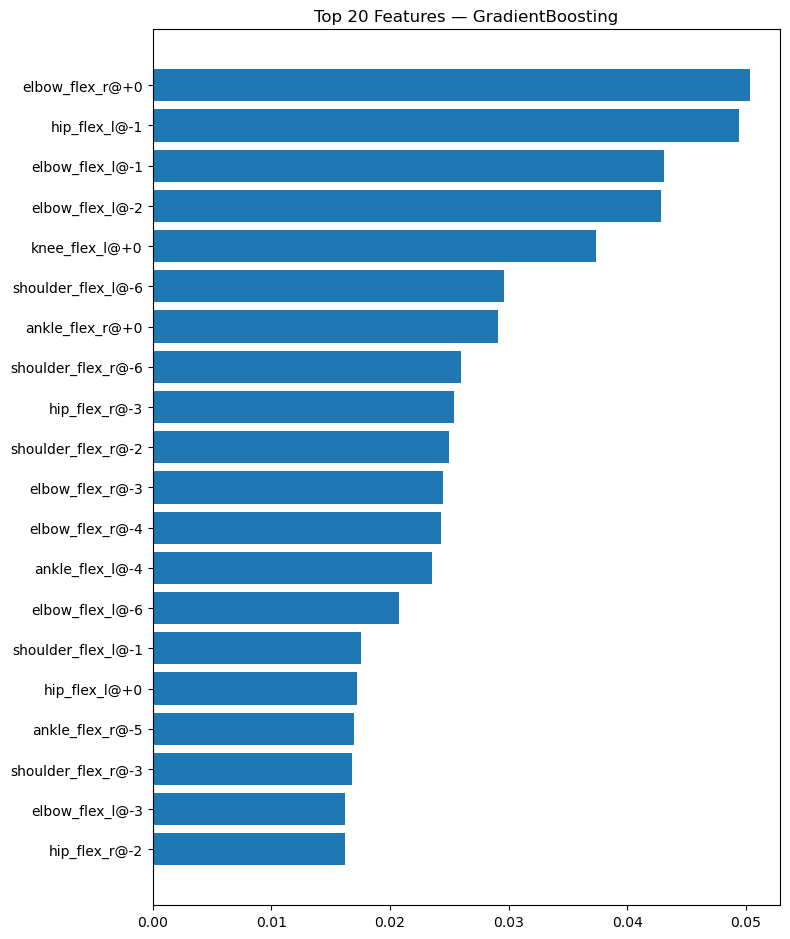

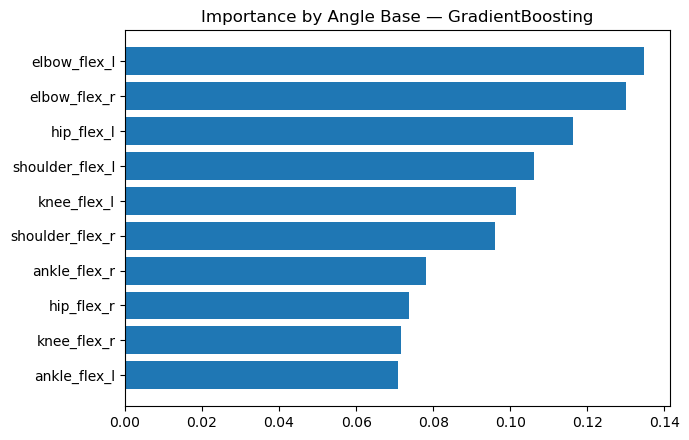

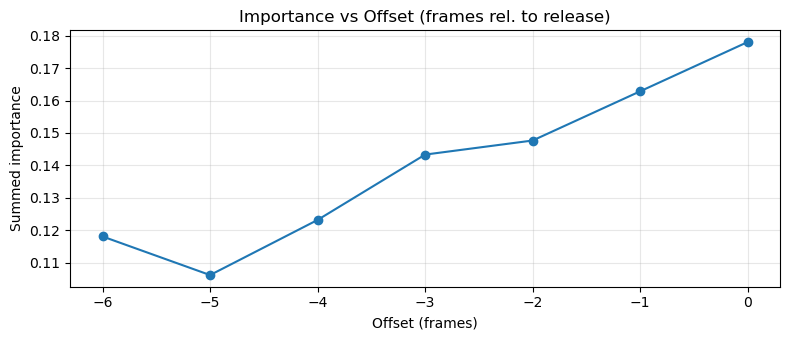

[INFO] mask@* feature importance share: 0.000


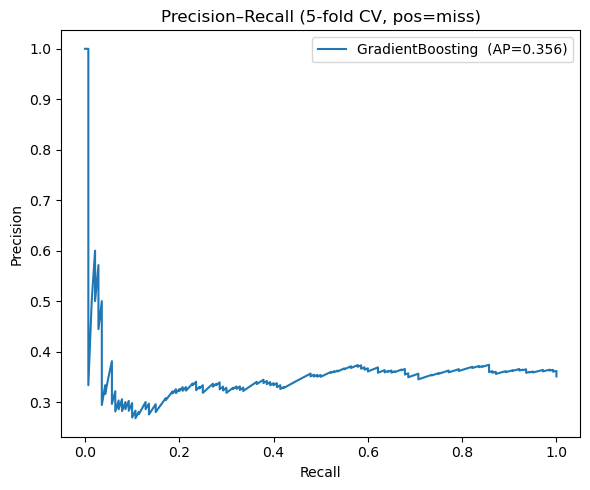

In [37]:
# =================================================
# B. During Model Building EDA — time_series aware
# =================================================
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# --- config ---
CHOSEN_MODEL = "GradientBoosting"   # or any key from best_models

# ------------- helpers -------------
def _final_estimator(est):
    return est.named_steps["clf"] if hasattr(est, "named_steps") and "clf" in est.named_steps else est

def _parse_offset(col: str):
    m = re.search(r'@([+-]?\d+)$', col or "")
    return int(m.group(1)) if m else None

def _angle_base(col: str):
    return col.split("@")[0] if isinstance(col, str) and "@" in col else None

def _get_importance_vector(clf, columns):
    """Return (importances, columns) aligned to X columns for trees/linear models."""
    if hasattr(clf, "feature_importances_"):
        imp = np.asarray(clf.feature_importances_, dtype=float)
        return imp, np.array(columns, dtype=object)

    if hasattr(clf, "coef_"):
        coef = np.asarray(clf.coef_, dtype=float)
        # binary: shape (1, n_features) typically; multiclass: (n_classes, n_features)
        if coef.ndim == 1:
            imp = np.abs(coef)
        else:
            # try to pick the row corresponding to POS_LABEL_INT; fallback to L2 over classes
            if hasattr(clf, "classes_") and POS_LABEL_INT in list(clf.classes_):
                row = list(clf.classes_).index(POS_LABEL_INT)
                imp = np.abs(coef[row])
            else:
                imp = np.linalg.norm(coef, axis=0)
        return imp, np.array(columns, dtype=object)

    return None, None  # non-linear non-explainable (e.g., RBF SVM without linear probe)

def _get_cv_scores(est, X, y, pos_label=0, n_splits=5, seed=42):
    """CV scores for the positive class using predict_proba/decision_function."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    if hasattr(est, "predict_proba"):
        proba = cross_val_predict(est, X, y, cv=cv, method="predict_proba")
        # classes_ order from inner estimator
        inner = _final_estimator(est)
        classes = list(getattr(inner, "classes_", [0,1]))
        idx = classes.index(pos_label) if pos_label in classes else 0
        scores = proba[:, idx]
    elif hasattr(est, "decision_function"):
        df = cross_val_predict(est, X, y, cv=cv, method="decision_function")
        if df.ndim == 1:
            # positive score is for classes_[1]; if pos=0 flip
            inner = _final_estimator(est)
            classes = list(getattr(inner, "classes_", [0,1]))
            scores = -df if (len(classes) == 2 and classes.index(pos_label) == 0) else df
        else:
            inner = _final_estimator(est)
            classes = list(getattr(inner, "classes_", [0,1]))
            idx = classes.index(pos_label) if pos_label in classes else 0
            scores = df[:, idx]
    else:
        scores = None
    return scores

# ------------- proceed -------------
if CHOSEN_MODEL not in best_models:
    print(f"[WARN] {CHOSEN_MODEL} not found in best_models; skip EDA.")
else:
    est = best_models[CHOSEN_MODEL]
    clf = _final_estimator(est)

    # ========= Feature Importance (trees / linear models) =========
    imp, cols = _get_importance_vector(clf, X_train.columns)
    if imp is not None:
        # overall top features
        k = min(20, len(imp))
        top_idx = np.argsort(imp)[::-1][:k]
        plt.figure(figsize=(8, 0.4*k + 1.5))
        plt.barh(range(k), imp[top_idx])
        plt.yticks(range(k), cols[top_idx])
        plt.title(f"Top {k} Features — {CHOSEN_MODEL}")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        # aggregate by angle base (exclude mask@)
        mask_mask = np.array([str(c).startswith("mask@") for c in cols])
        bases = np.array([_angle_base(c) for c in cols])
        valid = (~mask_mask) & (pd.Series(bases).notna().to_numpy())

        base_imp = {}
        for b, v in zip(bases[valid], imp[valid]):
            base_imp[b] = base_imp.get(b, 0.0) + float(v)
        if base_imp:
            items = sorted(base_imp.items(), key=lambda x: x[1], reverse=True)[:12]
            plt.figure(figsize=(7, 4.5))
            plt.barh([b for b,_ in items][::-1], [s for _,s in items][::-1])
            plt.title(f"Importance by Angle Base — {CHOSEN_MODEL}")
            plt.tight_layout()
            plt.show()

        # aggregate by offset (temporal salience), exclude mask@
        offs = np.array([_parse_offset(c) for c in cols])
        off_df = pd.DataFrame({"off": offs, "imp": imp, "is_mask": mask_mask})
        off_sum = off_df.loc[~off_df["is_mask"] & off_df["off"].notna()].groupby("off")["imp"].sum().sort_index()
        if len(off_sum) > 0:
            plt.figure(figsize=(8,3.5))
            plt.plot(off_sum.index.values, off_sum.values, marker="o")
            plt.title("Importance vs Offset (frames rel. to release)")
            plt.xlabel("Offset (frames)")
            plt.ylabel("Summed importance")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

        # mask share (info about padding dependence)
        mask_share = float(imp[mask_mask].sum()) / float(imp.sum() + 1e-12)
        print(f"[INFO] mask@* feature importance share: {mask_share:.3f}")

    else:
        print(f"[INFO] {CHOSEN_MODEL} has no native importance (e.g., RBF SVM). Skipping importance plots.")

    # ========= Precision–Recall Curve (Stratified CV) =========
    scores = _get_cv_scores(est, X_train, y_train, pos_label=POS_LABEL_INT, n_splits=5, seed=42)
    if scores is None:
        print(f"[WARN] {CHOSEN_MODEL} lacks predict_proba/decision_function; skipping PR curve.")
    else:
        prec, rec, _ = precision_recall_curve(y_train, scores, pos_label=POS_LABEL_INT)
        ap = average_precision_score((y_train == POS_LABEL_INT).astype(int), scores)
        plt.figure(figsize=(6,5))
        plt.plot(rec, prec, label=f"{CHOSEN_MODEL}  (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall (5-fold CV, pos=miss)")
        plt.legend()
        plt.tight_layout()
        plt.show()


In [38]:
# =================================================
# Step 3: Calibration & Threshold Tuning  (pos class = 0 = 'miss')
# =================================================
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score
)
from sklearn.base import clone
import numpy as np
import pandas as pd
from scipy.special import expit  # for decision_function -> prob mapping

PRECISION_FLOOR = 0.70  # precision floor used by one of the strategies
CALIB_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------
# Split training into sub-train / validation (stratified)
# ---------------------------
X_subtr, X_val, y_subtr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# ---------------------------
# Helpers (POS_LABEL-aware)  -> everything uses POS_LABEL_INT = 0
# ---------------------------
def pick_threshold(p, y, precision_floor=None, tmin=0.05, tmax=0.95, n=181, pos_label=POS_LABEL_INT):
    """Grid-search a threshold on probabilities p to maximize F1 (optionally with a precision floor)."""
    ts = np.linspace(tmin, tmax, n)
    best = {"t": 0.5, "precision": 0.0, "recall": 0.0, "f1": -1.0}

    for t in ts:
        pred = (p >= t).astype(int)
        prec = precision_score(y, pred, pos_label=pos_label, zero_division=0)
        rec  = recall_score(y, pred,    pos_label=pos_label, zero_division=0)
        f1   = f1_score(y, pred,        pos_label=pos_label, zero_division=0)

        if precision_floor is None:
            if f1 > best["f1"]:
                best = {"t": float(t), "precision": prec, "recall": rec, "f1": f1}
        else:
            if (prec >= precision_floor) and (f1 > best["f1"]):
                best = {"t": float(t), "precision": prec, "recall": rec, "f1": f1}

    # fallback if precision_floor was too strict
    if precision_floor is not None and best["f1"] < 0:
        return pick_threshold(p, y, precision_floor=None, tmin=tmin, tmax=tmax, n=n, pos_label=pos_label)

    return best

def _classes_of(est):
    """Get classes_ from estimator or final step of Pipeline/GridSearch."""
    if hasattr(est, "classes_"):
        return est.classes_
    if hasattr(est, "named_steps"):  # Pipeline
        last = list(est.named_steps.values())[-1]
        return _classes_of(last)
    if hasattr(est, "best_estimator_"):  # GridSearchCV
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")

def pos_proba(est, X, pos_label=POS_LABEL_INT):
    """Return P(y == pos_label) for any fitted estimator/pipeline."""
    classes = list(_classes_of(est))

    if hasattr(est, "predict_proba"):
        idx = classes.index(pos_label)
        return est.predict_proba(X)[:, idx]

    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        # Binary 1D case: scores are for classes_[1]; flip if our pos is classes_[0]
        if df.ndim == 1:
            s = df if (pos_label == classes[1]) else -df
        else:
            s = df[:, classes.index(pos_label)]
        return expit(s)

    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

def supports_calibration(base_est):
    return hasattr(base_est, "predict_proba") or hasattr(base_est, "decision_function")

# ---------------------------
# Calibration methods & strategies
# ---------------------------
calib_methods = ["none", "sigmoid", "isotonic"]  # "none" = use tuned model directly
strategies = {
    "f1_max":    {"precision_floor": None},
    "f1_at_p70": {"precision_floor": PRECISION_FLOOR},
}

# ---------------------------
# Run calibration + thresholding
# ---------------------------
results = []

for model_name, tuned_est in best_models.items():
    for method in calib_methods:
        # Work on a fresh clone each time
        base = clone(tuned_est)

        if method == "none":
            if not supports_calibration(base):
                print(f"[WARN] {model_name}: estimator lacks proba/decfunc; still fitting (no calibration).")
            model = base
            model.fit(X_subtr, y_subtr)
        else:
            if not supports_calibration(base):
                print(f"[WARN] {model_name}: does not support calibration; skipping '{method}'.")
                continue
            model = CalibratedClassifierCV(
                base, cv=CALIB_CV, method=method
            )
            model.fit(X_subtr, y_subtr)

        # Validation probabilities of 'miss' (class 0)
        p_val = pos_proba(model, X_val, pos_label=POS_LABEL_INT)

        # Threshold strategies
        s1 = pick_threshold(p_val, y_val, **strategies["f1_max"])
        s2 = pick_threshold(p_val, y_val, **strategies["f1_at_p70"])

        # Threshold-free metrics
        y_pos = (y_val == POS_LABEL_INT).astype(int)   # ensure correct orientation for ROC/AP
        ap  = average_precision_score(y_pos, p_val)
        roc = roc_auc_score(y_pos, p_val)

        # Record both strategies
        results.append({
            "model": model_name,
            "calibration": method,
            "strategy": "f1_max",
            "best_threshold": s1["t"],
            "precision(miss)": s1["precision"],
            "recall(miss)": s1["recall"],
            "f1(miss)": s1["f1"],
            "AP(pos=miss)": ap,
            "ROC_AUC": roc
        })
        results.append({
            "model": model_name,
            "calibration": method,
            "strategy": "f1_at_p70",
            "best_threshold": s2["t"],
            "precision(miss)": s2["precision"],
            "recall(miss)": s2["recall"],
            "f1(miss)": s2["f1"],
            "AP(pos=miss)": ap,
            "ROC_AUC": roc
        })

# ---------------------------
# Display Model Performance
# ---------------------------
calib_threshold_df = (
    pd.DataFrame(results)
    .sort_values(by=["model", "calibration", "strategy"])
    .reset_index(drop=True)
)

print("\n[CALIBRATION / THRESHOLD COMPARISON]")
display(calib_threshold_df)

summary = (
    calib_threshold_df
    .sort_values(["model", "f1(miss)"], ascending=[True, False])
    .groupby("model")
    .head(2)
    .reset_index(drop=True)
)

print("\n[TOP CHOICES PER MODEL]")
display(summary)

# ---------------------------
# Save Models and Thresholds
# ---------------------------
fitted_models = {}
best_thresholds = {}

for model_name, tuned_est in best_models.items():
    for method in calib_methods:
        if method != "none" and not supports_calibration(tuned_est):
            continue

        key = f"{model_name}_{method}"
        base = clone(tuned_est)

        if method == "none":
            model = base
            model.fit(X_subtr, y_subtr)
        else:
            model = CalibratedClassifierCV(base, cv=CALIB_CV, method=method)
            model.fit(X_subtr, y_subtr)

        fitted_models[key] = model

        # compute probabilities of 'miss' (class 0)
        p_val = pos_proba(model, X_val, pos_label=POS_LABEL_INT)

        # choose your strategy (here: max F1 on validation)
        best = pick_threshold(p_val, y_val, precision_floor=None, pos_label=POS_LABEL_INT)
        best_thresholds[key] = best["t"]

# Save CSVs
calib_threshold_df.to_csv(run_dir / "calibration_threshold_grid.csv", index=False)
summary.to_csv(run_dir / "calibration_threshold_summary.csv", index=False)
print(f"[INFO] Saved: {run_dir/'calibration_threshold_grid.csv'} and {run_dir/'calibration_threshold_summary.csv'}")



[CALIBRATION / THRESHOLD COMPARISON]


,model,calibration,strategy,best_threshold,precision(miss),recall(miss),f1(miss),AP(pos=miss),ROC_AUC
0,DecisionTree,isotonic,f1_at_p70,0.515,0.350000,1.000000,0.518519,0.391243,0.580357
1,DecisionTree,isotonic,f1_max,0.515,0.350000,1.000000,0.518519,0.391243,0.580357
2,DecisionTree,none,f1_at_p70,0.770,0.355263,0.964286,0.519231,0.405940,0.583104
3,DecisionTree,none,f1_max,0.770,0.355263,0.964286,0.519231,0.405940,0.583104
4,DecisionTree,sigmoid,f1_at_p70,0.375,0.363636,1.000000,0.533333,0.364945,0.541896
5,DecisionTree,sigmoid,f1_max,0.375,0.363636,1.000000,0.533333,0.364945,0.541896
6,GradientBoosting,isotonic,f1_at_p70,0.165,1.000000,0.035714,0.068966,0.382454,0.534684
7,GradientBoosting,isotonic,f1_max,0.510,0.354430,1.000000,0.523364,0.382454,0.534684
8,GradientBoosting,none,f1_at_p70,0.815,0.350000,1.000000,0.518519,0.398986,0.473214
9,GradientBoosting,none,f1_max,0.815,0.350000,1.000000,0.518519,0.398986,0.473214



[TOP CHOICES PER MODEL]


,model,calibration,strategy,best_threshold,precision(miss),recall(miss),f1(miss),AP(pos=miss),ROC_AUC
0,DecisionTree,sigmoid,f1_at_p70,0.375,0.363636,1.000000,0.533333,0.364945,0.541896
1,DecisionTree,sigmoid,f1_max,0.375,0.363636,1.000000,0.533333,0.364945,0.541896
2,GradientBoosting,isotonic,f1_max,0.510,0.354430,1.000000,0.523364,0.382454,0.534684
3,GradientBoosting,none,f1_at_p70,0.815,0.350000,1.000000,0.518519,0.398986,0.473214
4,KNN,isotonic,f1_at_p70,0.365,0.354430,1.000000,0.523364,0.379276,0.536401
5,KNN,isotonic,f1_max,0.365,0.354430,1.000000,0.523364,0.379276,0.536401
6,LinearSVC,sigmoid,f1_at_p70,0.425,0.373333,1.000000,0.543689,0.347180,0.486951
7,LinearSVC,sigmoid,f1_max,0.425,0.373333,1.000000,0.543689,0.347180,0.486951
8,LogisticRegression,sigmoid,f1_at_p70,0.425,0.373333,1.000000,0.543689,0.349391,0.492445
9,LogisticRegression,sigmoid,f1_max,0.425,0.373333,1.000000,0.543689,0.349391,0.492445


[INFO] Saved: /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/calibration_threshold_grid.csv and /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/calibration_threshold_summary.csv


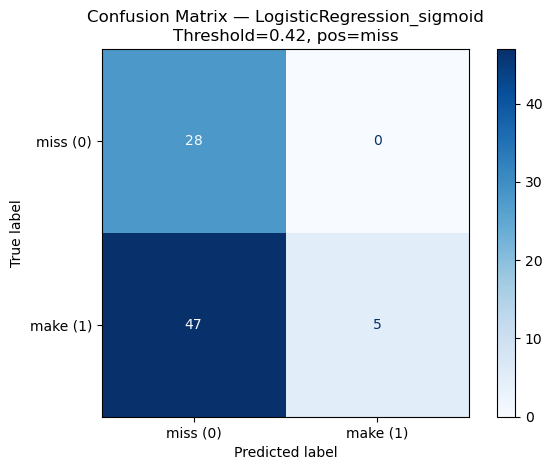

[VAL] P(miss) @ 0.42  —  Precision=0.373  Recall=1.000  F1=0.544  AP=0.349  ROC_AUC=0.492


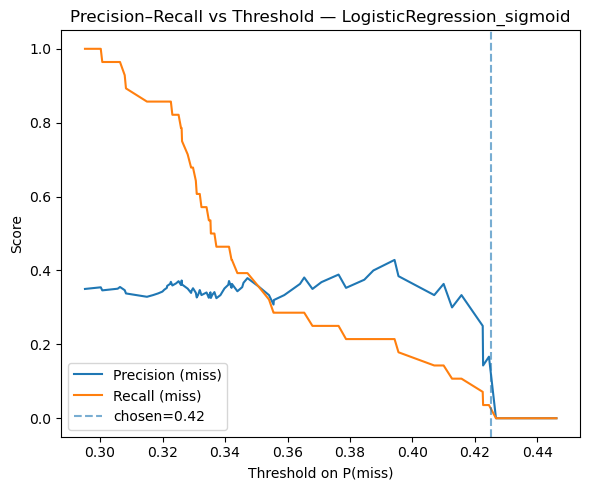

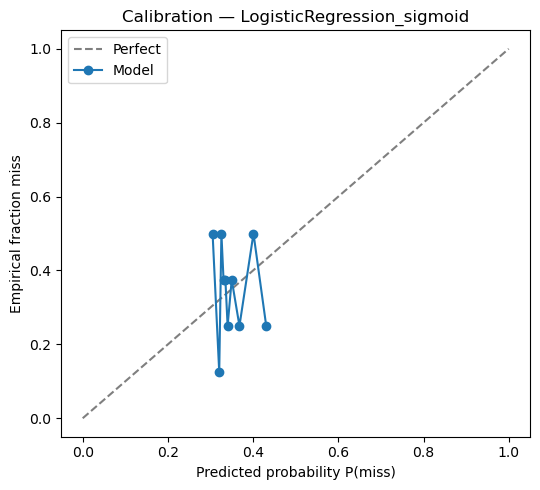


[Per-Session Validation Metrics]


,session,n,precision(miss),recall(miss),f1(miss),AP(pos=miss),ROC_AUC
0,session_01,3,0.666667,1.0,0.800000,0.833333,0.500000
1,session_04,32,0.428571,1.0,0.600000,0.353063,0.466667
2,session_02,17,0.375000,1.0,0.545455,0.500000,0.666667
3,session_03,28,0.285714,1.0,0.444444,0.296484,0.437500


In [39]:
# =================================================
# C. After Thresholding & Calibration — time_series aware
# =================================================
from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- config ---
CHOSEN_MODEL = "LogisticRegression_sigmoid"  # e.g., "RandomForest_none", "SVM_isotonic"
POS_LABEL_INT = 0                            # 0 = miss (positive class)
LABELS = ["miss (0)", "make (1)"]

# --- fetch model/threshold ---
if CHOSEN_MODEL not in fitted_models:
    raise KeyError(f"{CHOSEN_MODEL} not found in fitted_models.")
if CHOSEN_MODEL not in best_thresholds:
    raise KeyError(f"{CHOSEN_MODEL} not found in best_thresholds.")

best_calib_model = fitted_models[CHOSEN_MODEL]
thres = float(best_thresholds[CHOSEN_MODEL])

# --- probs for 'miss' on validation ---
p_val = pos_proba(best_calib_model, X_val, pos_label=POS_LABEL_INT)
y_pred_val = (p_val >= thres).astype(int)

# =================================================
# 1) Confusion Matrix
# =================================================
cm = confusion_matrix(y_val, y_pred_val, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {CHOSEN_MODEL}\nThreshold={thres:.2f}, pos=miss")
plt.tight_layout()
plt.show()

# Helpful summary line
prec = precision_score(y_val, y_pred_val, pos_label=POS_LABEL_INT, zero_division=0)
rec  = recall_score(y_val, y_pred_val,    pos_label=POS_LABEL_INT, zero_division=0)
f1   = f1_score(y_val, y_pred_val,        pos_label=POS_LABEL_INT, zero_division=0)
ap   = average_precision_score((y_val == POS_LABEL_INT).astype(int), p_val)
roc  = roc_auc_score((y_val == POS_LABEL_INT).astype(int), p_val)
print(f"[VAL] P(miss) @ {thres:.2f}  —  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  AP={ap:.3f}  ROC_AUC={roc:.3f}")

# =================================================
# 2) Precision–Recall vs Threshold
# =================================================
prec_curve, rec_curve, thr = precision_recall_curve(y_val, p_val, pos_label=POS_LABEL_INT)
plt.figure(figsize=(6,5))
plt.plot(thr, prec_curve[:-1], label="Precision (miss)")
plt.plot(thr, rec_curve[:-1],  label="Recall (miss)")
plt.axvline(thres, ls="--", alpha=0.6, label=f"chosen={thres:.2f}")
plt.xlabel("Threshold on P(miss)")
plt.ylabel("Score")
plt.title(f"Precision–Recall vs Threshold — {CHOSEN_MODEL}")
plt.legend()
plt.tight_layout()
plt.show()

# =================================================
# 3) Calibration (Reliability) Curve for P(miss)
# =================================================
frac_pos, bin_centers = calibration_curve(
    (y_val == POS_LABEL_INT).astype(int), p_val, n_bins=10, strategy="quantile"
)
plt.figure(figsize=(5.5,5))
plt.plot([0,1],[0,1], "k--", alpha=0.5, label="Perfect")
plt.plot(bin_centers, frac_pos, marker="o", label="Model")
plt.xlabel("Predicted probability P(miss)")
plt.ylabel("Empirical fraction miss")
plt.title(f"Calibration — {CHOSEN_MODEL}")
plt.legend()
plt.tight_layout()
plt.show()

# =================================================
# 4) Optional: Per-session diagnostics (if we can reconstruct idx_val)
# =================================================
try:
    # If you already built idx_val earlier, this uses it directly
    idx_val  # noqa: F401
    _has_idx = True
except NameError:
    _has_idx = False

if _has_idx:
    session_val = session_train.iloc[idx_val].reset_index(drop=True)
else:
    # Recreate the same split indices to align sessions with X_val/y_val
    # (uses same random_state and stratify=y_train as in Step 3)
    all_idx = np.arange(len(X_train))
    _, idx_val = train_test_split(
        all_idx, test_size=0.2, random_state=42, stratify=y_train
    )
    session_val = session_train.iloc[idx_val].reset_index(drop=True)

# Per-session table
per_rows = []
for sess in session_val.unique():
    mask = (session_val == sess).values
    if mask.sum() == 0:
        continue
    y_s   = y_val.iloc[mask]
    p_s   = p_val[mask]
    yhat  = (p_s >= thres).astype(int)
    y_pos = (y_s == POS_LABEL_INT).astype(int)
    prec_s = precision_score(y_s, yhat, pos_label=POS_LABEL_INT, zero_division=0)
    rec_s  = recall_score(y_s, yhat,    pos_label=POS_LABEL_INT, zero_division=0)
    f1_s   = f1_score(y_s, yhat,        pos_label=POS_LABEL_INT, zero_division=0)
    ap_s   = average_precision_score(y_pos, p_s) if y_pos.nunique() > 1 else np.nan
    roc_s  = roc_auc_score(y_pos, p_s) if y_pos.nunique() > 1 else np.nan
    per_rows.append({
        "session": sess, "n": int(mask.sum()),
        "precision(miss)": prec_s, "recall(miss)": rec_s, "f1(miss)": f1_s,
        "AP(pos=miss)": ap_s, "ROC_AUC": roc_s
    })

per_sess_df = pd.DataFrame(per_rows).sort_values("f1(miss)", ascending=False).reset_index(drop=True)
print("\n[Per-Session Validation Metrics]")
display(per_sess_df)


In [41]:
# =================================================
# Step 4: Full Training & Testing (Evaluation) — time_series aware
# =================================================
from joblib import dump
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)
from sklearn.base import clone
from scipy.special import expit  # for decision_function→prob mapping
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

# ----- Label constants (consistent across notebook) -----
LABELS = ["miss", "make"]   # 0 -> miss, 1 -> make
POS_LABEL_INT = 0           # positive class is 'miss'

# Use the train already built; keep test untouched
X_train_full = X_train
y_train_full = y_train

final_dir = run_dir / "final_eval"
final_dir.mkdir(parents=True, exist_ok=True)
print(f"[INFO] Saving final model evaluations to {final_dir}")

# Models to evaluate
chosen_models = [
    "LogisticRegression","KNN","DecisionTree",
    "RandomForest","GradientBoosting","SVM","LinearSVC",
]

# sanity checks
if 'best_models' not in globals():
    raise RuntimeError("best_models not found (run the hyperparameter tuning section first).")
if 'calib_threshold_df' not in globals():
    raise RuntimeError("calib_threshold_df not found (run the calibration/threshold section first).")

# --- utilities that respect pipelines and positive=0 ---
def _classes_of(est):
    if hasattr(est, "classes_"):
        return est.classes_
    if hasattr(est, "named_steps"):  # Pipeline
        last = list(est.named_steps.values())[-1]
        return _classes_of(last)
    if hasattr(est, "best_estimator_"):  # GridSearchCV
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")

def pos_proba(clf, X, pos_label=POS_LABEL_INT):
    classes = list(_classes_of(clf))
    # try predict_proba
    if hasattr(clf, "predict_proba"):
        idx = classes.index(pos_label)
        return clf.predict_proba(X)[:, idx]
    # fallback: decision_function → logistic
    if hasattr(clf, "decision_function"):
        df = clf.decision_function(X)
        if df.ndim == 1:
            # sklearn’s binary margin is for classes_[1]; flip if our pos is classes_[0]
            s = df if pos_label == classes[1] else -df
        else:
            s = df[:, classes.index(pos_label)]
        return expit(s)
    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

def supports_calibration(base_est):
    return hasattr(base_est, "predict_proba") or hasattr(base_est, "decision_function")

# Build: best calibration+threshold per model from calib_threshold_df
cfg_by_model = {}
for m in chosen_models:
    sub = calib_threshold_df[calib_threshold_df["model"] == m]
    if sub.empty:
        print(f"[WARN] No calibration rows for {m}; skipping.")
        continue
    row = sub.sort_values("f1(miss)", ascending=False).iloc[0]
    cfg_by_model[m] = {
        "calibration": row["calibration"],                     # "none" | "sigmoid" | "isotonic"
        "threshold": float(row["best_threshold"]),
        "strategy": row["strategy"],
        "val_F1(miss)": float(row["f1(miss)"]),
        "val_precision(miss)": float(row["precision(miss)"]),
        "val_recall(miss)": float(row["recall(miss)"]),
        "val_AP(pos=miss)": float(row["AP(pos=miss)"]),
        "val_ROC_AUC": float(row["ROC_AUC"]),
    }

final_results, saved_paths = [], []

for m in chosen_models:
    if m not in cfg_by_model:
        continue
    if m not in best_models:
        print(f"[WARN] No tuned pipeline in best_models for {m}; skipping.")
        continue
    tuned = best_models[m]
    method = cfg_by_model[m]["calibration"]
    thr    = cfg_by_model[m]["threshold"]

    print(f"\n=== {m}: train full (calibration={method}, thr={thr:.3f}) ===")

    # Fit the final estimator on ALL training data (jitter applies only in fit, not in predict)
    if method == "none":
        final_est = clone(tuned).fit(X_train_full, y_train_full)
    else:
        if not supports_calibration(tuned):
            print(f"[WARN] {m}: lacks proba/decision_function; forcing 'none' calibration.")
            final_est = clone(tuned).fit(X_train_full, y_train_full)
            method = "none"  # for logging
        else:
            final_est = CalibratedClassifierCV(clone(tuned), cv=5, method=method)
            final_est.fit(X_train_full, y_train_full)

    # predict on test (probabilities for 'miss' = class 0)
    p_test = pos_proba(final_est, X_test, pos_label=POS_LABEL_INT)  # P(miss)
    y_hat  = (p_test >= thr).astype(int)

    # orientation-safe metrics
    y_pos = (y_test == POS_LABEL_INT).astype(int)
    prec = precision_score(y_test, y_hat, pos_label=POS_LABEL_INT, zero_division=0)
    rec  = recall_score(y_test, y_hat,    pos_label=POS_LABEL_INT, zero_division=0)
    f1   = f1_score(y_test, y_hat,        pos_label=POS_LABEL_INT, zero_division=0)
    ap   = average_precision_score(y_pos, p_test)
    roc  = roc_auc_score(y_pos, p_test)
    bri  = brier_score_loss(y_test, p_test, pos_label=POS_LABEL_INT)  # OK because we pass pos_label
    cm   = confusion_matrix(y_test, y_hat, labels=[0,1])

    print(f"[TEST] {m}  P(miss)={prec:.3f} R(miss)={rec:.3f} F1(miss)={f1:.3f}  AP={ap:.3f}  ROC={roc:.3f}  Brier={bri:.3f}")
    print(pd.DataFrame(cm, index=["true miss (0)","true make (1)"], columns=["pred miss (0)","pred make (1)"]))

    # save model + plots
    tag = str(method).replace("/", "_")
    model_path = final_dir / f"{m}_cal-{tag}.joblib"
    dump(final_est, model_path)
    saved_paths.append(model_path.as_posix())

    try:
        fig_dir = final_dir / f"{m}_figs"
        save_all_eval_figures(
            outdir=fig_dir,
            y_true=y_test,
            y_pred=y_hat,
            y_proba=p_test,
            class_names=["miss (0)", "make (1)"]  # matches 0=miss, 1=make
        )
    except NameError:
        pass

    final_results.append({
        "model": m,
        "calibration": method,
        "threshold": thr,
        "val_metrics": cfg_by_model[m],
        "test_metrics": {
            "F1(miss)": float(f1),
            "precision(miss)": float(prec),
            "recall(miss)": float(rec),
            "AP(pos=miss)": float(ap),
            "ROC_AUC": float(roc),
            "Brier(pos=miss)": float(bri),
            "confusion_matrix": cm.tolist(),
        }
    })

# ---- Optional: per-session test metrics (time-series sanity check) ----
if "session_test" in globals():
    rows = []
    for sess in session_test.unique():
        mask = (session_test == sess).values
        if mask.sum() == 0:
            continue
        y_s   = y_test.iloc[mask]
        p_s   = p_test[mask]
        yhat  = (p_s >= thr).astype(int)
        y_pos = (y_s == POS_LABEL_INT).astype(int)
        rows.append({
            "session": sess,
            "n": int(mask.sum()),
            "F1(miss)": f1_score(y_s, yhat, pos_label=POS_LABEL_INT, zero_division=0),
            "precision(miss)": precision_score(y_s, yhat, pos_label=POS_LABEL_INT, zero_division=0),
            "recall(miss)": recall_score(y_s, yhat, pos_label=POS_LABEL_INT, zero_division=0),
            "AP(pos=miss)": average_precision_score(y_pos, p_s) if y_pos.nunique() > 1 else np.nan,
            "ROC_AUC": roc_auc_score(y_pos, p_s) if y_pos.nunique() > 1 else np.nan,
        })
    per_session_test = pd.DataFrame(rows).sort_values("F1(miss)", ascending=False).reset_index(drop=True)
    display(per_session_test)
    per_session_test.to_csv(final_dir / "per_session_test.csv", index=False)

# save summary
if final_results:
    final_df = pd.DataFrame([{
        "model": r["model"],
        "calibration": r["calibration"],
        "threshold": r["threshold"],
        "val_F1(miss)": r["val_metrics"]["val_F1(miss)"],
        "test_F1(miss)": r["test_metrics"]["F1(miss)"],
        "test_precision(miss)": r["test_metrics"]["precision(miss)"],
        "test_recall(miss)": r["test_metrics"]["recall(miss)"],
        "test_AP(pos=miss)": r["test_metrics"]["AP(pos=miss)"],
        "test_ROC_AUC": r["test_metrics"]["ROC_AUC"],
        "test_Brier(pos=miss)": r["test_metrics"]["Brier(pos=miss)"],
    } for r in final_results]).sort_values("test_F1(miss)", ascending=False).reset_index(drop=True)

    display(final_df)
    (final_dir / "final_results.json").write_text(json.dumps(final_results, indent=2))
    final_df.to_csv(final_dir / "final_results.csv", index=False)
    print(f"\n[INFO] Saved models:\n  - " + "\n  - ".join(saved_paths))
    print(f"[INFO] Results:\n  - {final_dir/'final_results.json'}\n  - {final_dir/'final_results.csv'}")
else:
    print("[WARN] Nothing trained—check chosen_models & that Step 3 produced calib_threshold_df rows.")


[INFO] Saving final model evaluations to /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/final_eval

=== LogisticRegression: train full (calibration=sigmoid, thr=0.425) ===
[TEST] LogisticRegression  P(miss)=0.366 R(miss)=1.000 F1(miss)=0.536  AP=0.332  ROC=0.449  Brier=0.233
               pred miss (0)  pred make (1)
true miss (0)             37              0
true make (1)             64              0


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== KNN: train full (calibration=isotonic, thr=0.365) ===
[TEST] KNN  P(miss)=0.400 R(miss)=0.595 F1(miss)=0.478  AP=0.365  ROC=0.468  Brier=0.234
               pred miss (0)  pred make (1)
true miss (0)             22             15
true make (1)             33             31


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== DecisionTree: train full (calibration=sigmoid, thr=0.375) ===
[TEST] DecisionTree  P(miss)=0.340 R(miss)=0.892 F1(miss)=0.493  AP=0.440  ROC=0.484  Brier=0.233
               pred miss (0)  pred make (1)
true miss (0)             33              4
true make (1)             64              0


...


=== LinearSVC: train full (calibration=sigmoid, thr=0.425) ===
[TEST] LinearSVC  P(miss)=0.366 R(miss)=1.000 F1(miss)=0.536  AP=0.350  ROC=0.478  Brier=0.233
               pred miss (0)  pred make (1)
true miss (0)             37              0
true make (1)             64              0


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


,session,n,F1(miss),precision(miss),recall(miss),AP(pos=miss),ROC_AUC
0,session_01,4,0.857143,0.750000,1.0,0.638889,0.000000
1,session_03,37,0.549020,0.378378,1.0,0.356329,0.428571
2,session_02,20,0.518519,0.350000,1.0,0.312245,0.351648
3,session_04,40,0.490566,0.325000,1.0,0.414212,0.598291


,model,calibration,threshold,val_F1(miss),test_F1(miss),test_precision(miss),test_recall(miss),test_AP(pos=miss),test_ROC_AUC,test_Brier(pos=miss)
0,RandomForest,isotonic,0.410,0.568421,0.536585,0.383721,0.891892,0.394830,0.488176,0.237553
1,LogisticRegression,sigmoid,0.425,0.543689,0.536232,0.366337,1.000000,0.332305,0.449324,0.233426
2,GradientBoosting,isotonic,0.510,0.523364,0.536232,0.366337,1.000000,0.478658,0.582981,0.229376
3,LinearSVC,sigmoid,0.425,0.543689,0.536232,0.366337,1.000000,0.350363,0.478041,0.232932
4,SVM,isotonic,0.420,0.528736,0.522388,0.360825,0.945946,0.427725,0.547720,0.236105
5,DecisionTree,sigmoid,0.375,0.533333,0.492537,0.340206,0.891892,0.439679,0.484375,0.233391
6,KNN,isotonic,0.365,0.523364,0.478261,0.400000,0.594595,0.364644,0.468328,0.233508



[INFO] Saved models:
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/final_eval/LogisticRegression_cal-sigmoid.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/final_eval/KNN_cal-isotonic.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/final_eval/DecisionTree_cal-sigmoid.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/final_eval/RandomForest_cal-isotonic.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/final_eval/GradientBoosting_cal-isotonic.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-53-43_run-001_baseline/final_eval/SVM_cal-isotonic.joblib
  - /Users/kwill55/RVL

[Final Test Classification Report]  (positive = 'miss'=0)
              precision    recall  f1-score   support

    miss (0)       0.37      0.95      0.53        37
    make (1)       0.71      0.08      0.14        64

    accuracy                           0.40       101
   macro avg       0.54      0.51      0.34       101
weighted avg       0.59      0.40      0.29       101



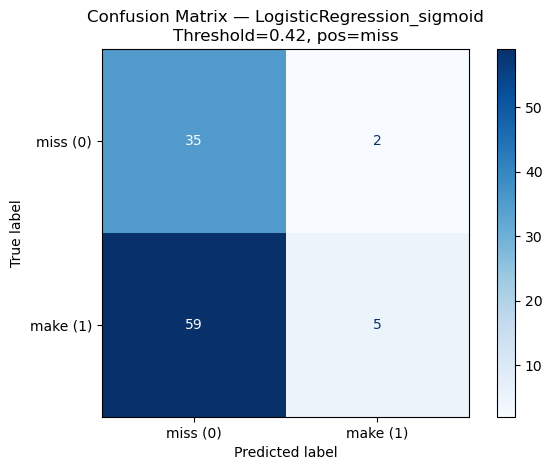

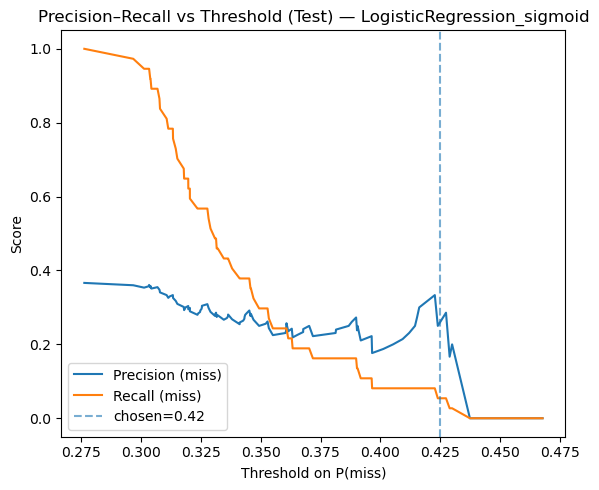

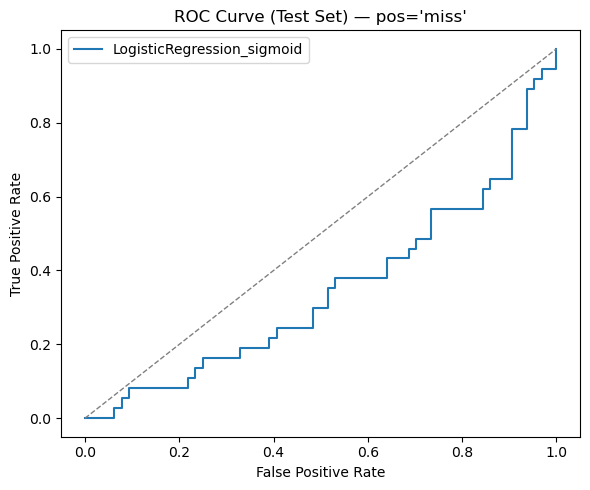

[TEST] AP(pos=miss)=0.296  ROC_AUC=0.345


In [42]:
# =================================================
# D. Final Test Evaluation  (pos class = 0 = 'miss')
# =================================================
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, average_precision_score, roc_auc_score
)
import numpy as np
import matplotlib.pyplot as plt

# Pick the calibrated model you want to report 
CHOSEN_MODEL = "LogisticRegression_sigmoid"   # e.g., "RandomForest_none"
POS_LABEL_INT = 0
LABELS = ["miss", "make"]  # display order

# --- safety checks ---
if CHOSEN_MODEL not in fitted_models:
    raise KeyError(f"{CHOSEN_MODEL} not found in fitted_models.")
if CHOSEN_MODEL not in best_thresholds:
    raise KeyError(f"{CHOSEN_MODEL} not found in best_thresholds.")

final_model = fitted_models[CHOSEN_MODEL]
thr_chosen = float(best_thresholds[CHOSEN_MODEL])

# --- Probabilities for positive class = miss (0) on TEST set ---
p_test = pos_proba(final_model, X_test, pos_label=POS_LABEL_INT)  # P(miss)
y_pred_test = (p_test >= thr_chosen).astype(int)

# -------- Classification report (test) --------
print("[Final Test Classification Report]  (positive = 'miss'=0)")
print(classification_report(
    y_test,
    y_pred_test,
    labels=[0, 1],                         # 0 -> miss, 1 -> make
    target_names=["miss (0)", "make (1)"],
    zero_division=0
))

# -------- Confusion Matrix (test @ chosen threshold) --------
cm = confusion_matrix(y_test, y_pred_test, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["miss (0)", "make (1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {CHOSEN_MODEL}\nThreshold={thr_chosen:.2f}, pos=miss")
plt.tight_layout()
plt.show()

# -------- Precision–Recall vs Threshold (test) --------
prec_curve, rec_curve, thr_curve = precision_recall_curve(
    y_test, p_test, pos_label=POS_LABEL_INT
)
plt.figure(figsize=(6,5))
plt.plot(thr_curve, prec_curve[:-1], label="Precision (miss)")
plt.plot(thr_curve, rec_curve[:-1],  label="Recall (miss)")
plt.axvline(thr_chosen, ls="--", alpha=0.6, label=f"chosen={thr_chosen:.2f}")
plt.xlabel("Threshold on P(miss)")
plt.ylabel("Score")
plt.title(f"Precision–Recall vs Threshold (Test) — {CHOSEN_MODEL}")
plt.legend()
plt.tight_layout()
plt.show()

# -------- ROC curve (test) using P(miss) --------
fpr, tpr, _ = roc_curve(y_test, p_test, pos_label=POS_LABEL_INT)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{CHOSEN_MODEL}")
plt.plot([0,1], [0,1], "--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Test Set) — pos='miss'")
plt.legend()
plt.tight_layout()
plt.show()

# -------- Threshold-free summary (useful for report) --------
ap_test  = average_precision_score((y_test == POS_LABEL_INT).astype(int), p_test)
roc_test = roc_auc_score((y_test == POS_LABEL_INT).astype(int), p_test)
print(f"[TEST] AP(pos=miss)={ap_test:.3f}  ROC_AUC={roc_test:.3f}")


In [27]:
# ============================================================
# STEP 5 (FAST MODE): Diagnostics of final models  (pos class = 0 = 'miss')
# ============================================================
import os
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import load
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)

# --------------------------
# FAST MODE toggles (tune these on laptop vs HPC)
# --------------------------
FAST_MODE        = True     # 👈 set False for full/heavy run
DO_PER_FEATURE   = False    # per-feature PI (heavy). In FAST_MODE keep False.
DO_GROUP_ANGLE   = True     # group PI by angle base (e.g., elbow_flex@*)
DO_GROUP_OFFSET  = True     # group PI by offset (e.g., *@-10)
N_REPEATS_FAST   = 3        # PI repeats in FAST_MODE
N_REPEATS_FULL   = 20       # PI repeats in full mode
N_JOBS_FAST      = 2        # limit CPU cores on laptop
N_JOBS_FULL      = -1       # use all cores on big iron
MAX_FEATURES_PI  = 200      # cap per-feature PI to N columns (None = all)
PRIORITY_OFFSETS = [-30, -15, -5, 0, 5, 15, 30]  # offsets to keep first if sampling

# (Optional) avoid BLAS thread oversubscription
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

# --------------------------
# Constants (keep consistent)
# --------------------------
LABELS = ["miss", "make"]   # 0 -> miss, 1 -> make
POS_LABEL_INT = 0

# --------------------------
# Paths & inputs
# --------------------------
final_dir = run_dir / "final_eval"
results_json = final_dir / "final_results.json"
if not results_json.exists():
    raise FileNotFoundError(f"Expected {results_json} from Step 4 at: {results_json}")

with results_json.open() as f:
    final_results = json.load(f)

X_train_full = X_train
y_train_full = y_train

diag_root = run_dir / "diagnostics_final"
diag_root.mkdir(parents=True, exist_ok=True)

# Prefer validation set (if present) for permutation importance; else test
if 'X_val' in globals() and 'y_val' in globals():
    use_X_perm, use_y_perm, perm_where = X_val, y_val, "val"
else:
    use_X_perm, use_y_perm, perm_where = X_test, y_test, "test"
print(f"[INFO] Permutation importance will run on: {perm_where} set")

# --------------------------
# Helpers (POS_LABEL-aware + parsing)
# --------------------------
def _classes_of(est):
    if hasattr(est, "classes_"):
        return est.classes_
    if hasattr(est, "named_steps"):
        last = list(est.named_steps.values())[-1]
        return _classes_of(last)
    if hasattr(est, "best_estimator_"):
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")

def _expit_stable(x):
    x = np.asarray(x, dtype=float)
    x = np.clip(x, -35, 35)
    return 1.0 / (1.0 + np.exp(-x))

def pos_proba(est, X, pos_label=POS_LABEL_INT):
    """Return P(y == pos_label). Works with Pipeline; falls back to decision_function."""
    classes = list(_classes_of(est))
    if hasattr(est, "predict_proba"):
        idx = classes.index(pos_label)
        return est.predict_proba(X)[:, idx]
    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        if df.ndim == 1:
            s = df if pos_label == classes[1] else -df
        else:
            s = df[:, classes.index(pos_label)]
        return _expit_stable(s)
    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

def _parse_offset(col: str):
    m = re.search(r'@([+-]?\d+)$', str(col))
    return int(m.group(1)) if m else None

def _angle_base(col: str):
    return col.split('@')[0] if isinstance(col, str) and '@' in col else None

# --------------------------
# Scorers for PI (orientation-safe)
# --------------------------
def scorer_roc(est, X, y):
    p = pos_proba(est, X, pos_label=POS_LABEL_INT)
    return roc_auc_score((y == POS_LABEL_INT).astype(int), p)

def scorer_ap(est, X, y):
    p = pos_proba(est, X, pos_label=POS_LABEL_INT)
    return average_precision_score((y == POS_LABEL_INT).astype(int), p)

def scorer_f1_at(thr):
    def _f(est, X, y):
        p = pos_proba(est, X, pos_label=POS_LABEL_INT)
        yhat = (p >= thr).astype(int)
        return f1_score(y, yhat, pos_label=POS_LABEL_INT, zero_division=0)
    return _f

# --------------------------
# Group permutation (cheap & interpretable for time-series)
# --------------------------
def group_perm_importance(estimator, X, y, groups: dict, scorer, n_repeats=8, random_state=42):
    """
    Permute row order as a block for each group of columns; compute drop in scorer.
    groups: dict[name -> list[str column names]]
    Returns: DataFrame[group, delta_mean, delta_std, baseline, score_mean, n_features]
    """
    rng = np.random.RandomState(random_state)
    baseline = scorer(estimator, X, y)
    rows = []
    for gname, gcols in groups.items():
        if not gcols:
            continue
        deltas = []
        for _ in range(n_repeats):
            Xp = X.copy()
            idx = rng.permutation(len(Xp))
            Xp[gcols] = Xp[gcols].iloc[idx].to_numpy()
            s = scorer(estimator, Xp, y)
            deltas.append(baseline - s)
        deltas = np.array(deltas, float)
        rows.append({
            "group": gname,
            "delta_mean": deltas.mean(),
            "delta_std": deltas.std(ddof=1) if len(deltas) > 1 else 0.0,
            "baseline": baseline,
            "score_mean": baseline - deltas.mean(),
            "n_features": len(gcols),
        })
    return pd.DataFrame(rows).sort_values("delta_mean", ascending=False).reset_index(drop=True)

# --------------------------
# Per-feature PI wrapper (optional/heavy)
# --------------------------
def per_feature_pi(estimator, X_perm, y_perm, feature_names, mode="roc_auc", n_repeats=5, n_jobs=2):
    if mode == "roc_auc":
        scoring = scorer_roc
    elif mode == "average_precision":
        scoring = scorer_ap
    else:
        raise ValueError("mode must be 'roc_auc' or 'average_precision'")
    res = permutation_importance(
        estimator, X_perm, y_perm,
        scoring=scoring, n_repeats=n_repeats,
        random_state=42, n_jobs=n_jobs
    )
    df = pd.DataFrame({
        "feature": feature_names,
        "perm_importance_mean": res.importances_mean,
        "perm_importance_std":  res.importances_std
    }).sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)
    # TS-aware annotations
    df["is_mask"] = df["feature"].astype(str).str.startswith("mask@")
    df["angle_base"] = df["feature"].map(_angle_base)
    df["offset"] = df["feature"].map(_parse_offset)
    return df

# --------------------------
# FAST mode config
# --------------------------
N_REPEATS_PI = N_REPEATS_FAST if FAST_MODE else N_REPEATS_FULL
N_JOBS_PI    = N_JOBS_FAST    if FAST_MODE else N_JOBS_FULL

# Feature subset for per-feature PI (if enabled)
all_feat_names = list(X_train_full.columns)
feat_subset = all_feat_names
if DO_PER_FEATURE and FAST_MODE and MAX_FEATURES_PI is not None:
    # prioritize canonical offsets, then random fill
    pri = [c for c in all_feat_names if _parse_offset(c) in set(PRIORITY_OFFSETS)]
    remain = [c for c in all_feat_names if c not in pri]
    rng = np.random.RandomState(42)
    rng.shuffle(remain)
    feat_subset = (pri + remain)[:MAX_FEATURES_PI]
    # align X for permutation set
    use_X_perm = use_X_perm[feat_subset]

# --------------------------
# Build groups for group PI
# --------------------------
angle_groups = {}
offset_groups = {}
for c in all_feat_names:
    if not isinstance(c, str) or '@' not in c or c.startswith("mask@"):
        continue
    base = _angle_base(c)
    off  = _parse_offset(c)
    if base:
        angle_groups.setdefault(base, []).append(c)
    if off is not None:
        offset_groups.setdefault(off, []).append(c)

# --------------------------
# Loop over final models (from Step 4 results)
# --------------------------
summary_rows = []

for entry in final_results:
    m        = entry["model"]
    method   = entry["calibration"]          # "none" | "sigmoid" | "isotonic"
    thr      = float(entry["threshold"])

    tag = str(method).replace("/", "_")
    model_path = final_dir / f"{m}_cal-{tag}.joblib"
    if not model_path.exists():
        print(f"[WARN] Missing saved model for {m} at {model_path}; skipping.")
        continue

    print(f"\n=== {m} | load final model | calibration={method} | threshold={thr:.3f} ===")
    cal = load(model_path)

    # --- Test performance (pos = 'miss' = 0) ---
    p_test = pos_proba(cal, X_test, pos_label=POS_LABEL_INT)  # P(miss)
    y_hat  = (p_test >= thr).astype(int)

    y_pos_test = (y_test == POS_LABEL_INT).astype(int)
    prec = precision_score(y_test, y_hat, pos_label=POS_LABEL_INT, zero_division=0)
    rec  = recall_score(y_test, y_hat,    pos_label=POS_LABEL_INT, zero_division=0)
    f1   = f1_score(y_test, y_hat,        pos_label=POS_LABEL_INT, zero_division=0)
    ap   = average_precision_score(y_pos_test, p_test)
    roc  = roc_auc_score(y_pos_test, p_test)
    bri  = brier_score_loss(y_test, p_test, pos_label=POS_LABEL_INT)
    cm   = confusion_matrix(y_test, y_hat, labels=[0, 1])

    print(f"[TEST] P(miss)={prec:.3f} R(miss)={rec:.3f} F1(miss)={f1:.3f}  AP(pos=miss)={ap:.3f}  ROC={roc:.3f}  Brier(pos=miss)={bri:.3f}")
    print(pd.DataFrame(cm,
        index=["true miss (0)","true make (1)"],
        columns=["pred miss (0)","pred make (1)"]
    ))

    outdir = (diag_root / m)
    outdir.mkdir(parents=True, exist_ok=True)

    # --- Group permutation (cheap & TS-aware) ---
    if DO_GROUP_ANGLE:
        gpi_angle_roc = group_perm_importance(cal, use_X_perm, use_y_perm, angle_groups,
                                              scorer=scorer_roc, n_repeats=N_REPEATS_PI)
        gpi_angle_roc.to_csv(outdir / f"group_perm_by_angle_roc_on_{perm_where}.csv", index=False)

        gpi_angle_f1  = group_perm_importance(cal, use_X_perm, use_y_perm, angle_groups,
                                              scorer=scorer_f1_at(thr), n_repeats=N_REPEATS_PI)
        gpi_angle_f1.to_csv(outdir / f"group_perm_by_angle_f1_thr{thr:.3f}_on_{perm_where}.csv", index=False)

    if DO_GROUP_OFFSET:
        gpi_off_roc = group_perm_importance(cal, use_X_perm, use_y_perm, offset_groups,
                                            scorer=scorer_roc, n_repeats=N_REPEATS_PI)
        gpi_off_roc.sort_values("group").to_csv(outdir / f"group_perm_by_offset_roc_on_{perm_where}.csv", index=False)

        gpi_off_f1  = group_perm_importance(cal, use_X_perm, use_y_perm, offset_groups,
                                            scorer=scorer_f1_at(thr), n_repeats=N_REPEATS_PI)
        gpi_off_f1.sort_values("group").to_csv(outdir / f"group_perm_by_offset_f1_thr{thr:.3f}_on_{perm_where}.csv", index=False)

    # --- Optional per-feature PI (heavy; disabled in FAST_MODE) ---
    if DO_PER_FEATURE:
        print(f"[INFO] Per-feature PI on {len(feat_subset)} features "
              f"({ 'FAST' if FAST_MODE else 'FULL' }): repeats={N_REPEATS_PI}, n_jobs={N_JOBS_PI}")
        pf_roc = per_feature_pi(cal, use_X_perm, use_y_perm, feat_subset,
                                mode="roc_auc", n_repeats=N_REPEATS_PI, n_jobs=N_JOBS_PI)
        pf_roc.to_csv(outdir / f"importance_perm_rocauc_on_{perm_where}.csv", index=False)

        pf_ap = per_feature_pi(cal, use_X_perm, use_y_perm, feat_subset,
                               mode="average_precision", n_repeats=N_REPEATS_PI, n_jobs=N_JOBS_PI)
        pf_ap.to_csv(outdir / f"importance_perm_average_precision_on_{perm_where}.csv", index=False)

    # --- Summary row ---
    summary_rows.append({
        "model": m, "calibration": method, "threshold": thr,
        "precision(miss)": float(prec), "recall(miss)": float(rec), "f1(miss)": float(f1),
        "AP(pos=miss)": float(ap), "ROC_AUC": float(roc), "Brier(pos=miss)": float(bri),
    })

# --------------------------
# Roll-up table
# --------------------------
if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values("f1(miss)", ascending=False).reset_index(drop=True)
    display(summary_df)
    summary_df.to_csv(diag_root / ("summary_across_models_FAST.csv" if FAST_MODE else "summary_across_models.csv"),
                      index=False)
    print(f"\n[INFO] Diagnostics written under: {diag_root}")
else:
    print("[WARN] No models diagnosed — check Step 4 outputs in", final_dir)


[INFO] Permutation importance will run on: val set

=== LogisticRegression | load final model | calibration=sigmoid | threshold=0.425 ===
[TEST] P(miss)=0.366 R(miss)=1.000 F1(miss)=0.536  AP(pos=miss)=0.332  ROC=0.449  Brier(pos=miss)=0.233
               pred miss (0)  pred make (1)
true miss (0)             37              0
true make (1)             64              0

=== KNN | load final model | calibration=isotonic | threshold=0.365 ===
[TEST] P(miss)=0.400 R(miss)=0.595 F1(miss)=0.478  AP(pos=miss)=0.365  ROC=0.468  Brier(pos=miss)=0.234
               pred miss (0)  pred make (1)
true miss (0)             22             15
true make (1)             33             31

=== DecisionTree | load final model | calibration=sigmoid | threshold=0.375 ===
[TEST] P(miss)=0.340 R(miss)=0.892 F1(miss)=0.493  AP(pos=miss)=0.440  ROC=0.484  Brier(pos=miss)=0.233
               pred miss (0)  pred make (1)
true miss (0)             33              4
true make (1)             64              0


,model,calibration,threshold,precision(miss),recall(miss),f1(miss),AP(pos=miss),ROC_AUC,Brier(pos=miss)
0,RandomForest,isotonic,0.410,0.383721,0.891892,0.536585,0.394830,0.488176,0.237553
1,LogisticRegression,sigmoid,0.425,0.366337,1.000000,0.536232,0.332305,0.449324,0.233426
2,GradientBoosting,isotonic,0.510,0.366337,1.000000,0.536232,0.478658,0.582981,0.229376
3,LinearSVC,sigmoid,0.425,0.366337,1.000000,0.536232,0.350363,0.478041,0.232932
4,SVM,isotonic,0.420,0.360825,0.945946,0.522388,0.427725,0.547720,0.236105
5,DecisionTree,sigmoid,0.375,0.340206,0.891892,0.492537,0.439679,0.484375,0.233391
6,KNN,isotonic,0.365,0.400000,0.594595,0.478261,0.364644,0.468328,0.233508



[INFO] Diagnostics written under: /Users/kwill55/RVL/personalized-sports-optimization/experiments/time_series/2025-09-02_10-48-28_run-001_baseline/diagnostics_final
